## Bachelor Thesis: Early Detection of Skin Diseases
---
**Inspiration work**: https://github.com/SpyrosAlvanakis/DNN_Ham10000/tree/main

**Author:** Asadulla Ravshanbekov 

# Data Analysis

**Objective:** To perform dataset analysis as a crucial step in understanding the data and extracting meaningful insights for the early detection of skin diseases.

In [1]:
#ignorance
import warnings

# Suppress FutureWarning and UserWarning for cleaner output
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

In [2]:
# essential imports 
import os
import glob
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import random

from PIL import Image
import cv2

In [3]:
metadata_path = os.path.join('/home/asad/Thesis Practical part/dataset/HAM10000_metadata.csv')
metadata = pd.read_csv(metadata_path)

In [4]:
metadata.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


In [5]:
metadata.shape

(10015, 7)

**ANALYSE THE CLASS DISTRIBUTION**

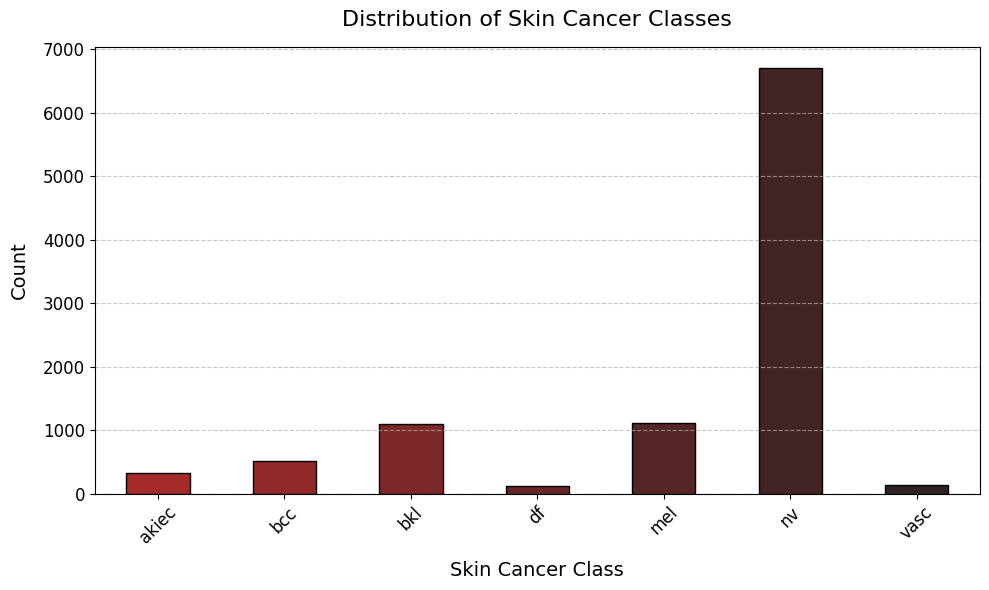

In [6]:
# Count the occurrences of each class in the 'dx' column and sort by index
count = metadata.dx.value_counts().sort_index()

# Extract unique class labels
unique_vals = count.index

# Generate a dark brown color palette
dark_brown_colors = sns.dark_palette("brown", n_colors=len(unique_vals), reverse=True)

# Create a bar plot for the class distribution
fig, ax = plt.subplots(figsize=(10, 6))
count.plot(
    kind='bar',
    color=dark_brown_colors,
    edgecolor='black',
    ax=ax
)

# Enhance plot aesthetics
ax.set_xlabel('Skin Cancer Class', fontsize=14, labelpad=10)
ax.set_ylabel('Count', fontsize=14, labelpad=10)
ax.set_title('Distribution of Skin Cancer Classes', fontsize=16, pad=15)
ax.tick_params(axis='x', rotation=45, labelsize=12)
ax.tick_params(axis='y', labelsize=12)

# Add gridlines for better readability
ax.grid(axis='y', linestyle='--', alpha=0.7)

# Display the plot
plt.tight_layout()
plt.show()

**CLEANING OF DATA** 

**Handling Missing Data:**

To address missing values, I will impute them using the mean of their respective category, as the column contains floating-point numbers.

In [7]:
def check_for_missing_data(df):
    # Create a summary DataFrame with column names and their data types
    summary = pd.DataFrame(df.dtypes, columns=['dtypes'])
    summary = summary.reset_index()
    summary['Name'] = summary['index']
    summary = summary[['Name', 'dtypes']]
    
    # Add a column to count the number of missing values for each column
    summary['Missing'] = df.isnull().sum().values
    
    # Return the summary DataFrame
    return summary

In [8]:
check_for_missing_data(metadata)

,Name,dtypes,Missing
0,lesion_id,object,0
1,image_id,object,0
2,dx,object,0
3,dx_type,object,0
4,age,float64,57
5,sex,object,0
6,localization,object,0


In [9]:
# Fill missing values in the 'age' column with the mean age
metadata['age'] = metadata['age'].fillna(metadata['age'].mean())

In [10]:
def convert_float_to_int(df, column_name):
    """
    Converts a specified column in a DataFrame from float to integer type, 
    if the column's data type is float64.

    Parameters:
    df (pd.DataFrame): The DataFrame containing the column to be converted.
    column_name (str): The name of the column to convert.

    Returns:
    pd.DataFrame: The updated DataFrame with the specified column converted to integer type.
    """
    # Check if the column's data type is float64
    if df[column_name].dtype == 'float64':
        # Convert the column to integer type
        df[column_name] = df[column_name].astype(int)
    return df

In [11]:
metadata = convert_float_to_int(metadata,'age')
metadata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10015 entries, 0 to 10014
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   lesion_id     10015 non-null  object
 1   image_id      10015 non-null  object
 2   dx            10015 non-null  object
 3   dx_type       10015 non-null  object
 4   age           10015 non-null  int64 
 5   sex           10015 non-null  object
 6   localization  10015 non-null  object
dtypes: int64(1), object(6)
memory usage: 547.8+ KB


**CLEAN THE DUPLICATES**

In [12]:
def check_for_duplicate_rows(df):
    """
    Function to check for duplicate rows and null entries in a DataFrame.

    Parameters:
    df (pd.DataFrame): The DataFrame to check for duplicates and null values.

    Returns:
    None: Prints the number of samples, duplicated entries, and null entries.
    """
    # Get the total number of rows and columns in the DataFrame
    num_rows, num_cols = df.shape

    # Calculate the number of duplicate rows in the DataFrame
    num_duplicates = df.duplicated().sum()

    # Calculate the number of null values for each column
    null_counts = df.isnull().sum()

    # Log the results for better readability
    print(f"DataFrame Analysis:")
    print(f"-------------------")
    print(f"Total Samples: {num_rows}")
    print(f"Total Features: {num_cols}")
    print(f"Duplicated Entries: {num_duplicates}")
    print(f"Null Entries by Column:\n{null_counts}")

In [13]:
check_for_duplicate_rows(metadata)

DataFrame Analysis:
-------------------
Total Samples: 10015
Total Features: 7
Duplicated Entries: 0
Null Entries by Column:
lesion_id       0
image_id        0
dx              0
dx_type         0
age             0
sex             0
localization    0
dtype: int64


In [14]:
# Count the occurrences of each unique lesion ID
lesion_id_cnt = metadata['lesion_id'].value_counts()

def check_duplicates_lesions(lesion_id):
    """
    Check if a given lesion ID has duplicate entries in the dataset.

    Parameters:
    lesion_id (str): The lesion ID to check.

    Returns:
    bool: True if the lesion ID has duplicates, False otherwise.
    """
    # Return True if the lesion ID appears more than once, otherwise False
    return lesion_id_cnt[lesion_id] > 1

# Map the check_duplicates_lesions function to the 'lesion_id' column
# Create a new column 'dup_les' to indicate whether a lesion ID has duplicates
metadata['dup_les'] = metadata['lesion_id'].map(check_duplicates_lesions)

In [15]:
# Count the occurrences of True and False in the 'dup_les' column
# This helps to understand how many duplicate lesion IDs exist in the dataset
duplicate_counts = metadata['dup_les'].value_counts()

# Display the counts for better clarity
print("Counts of duplicate lesion IDs (True indicates duplicates):")
print(duplicate_counts)

Counts of duplicate lesion IDs (True indicates duplicates):
dup_les
False    5514
True     4501
Name: count, dtype: int64


In [16]:
# Filter the metadata DataFrame to retain only rows where 'dup_les' is False
# This ensures that only unique lesion entries are kept in the dataset
metadata = metadata[~metadata['dup_les']]

# Log the shape of the filtered DataFrame for verification
# This provides insight into the number of rows and columns after filtering
num_rows, num_cols = metadata.shape
print(f"Filtered metadata: {num_rows} rows and {num_cols} columns remaining.")

Filtered metadata: 5514 rows and 8 columns remaining.


**LOAD THE IMAGE PATHS**

In [17]:
# Define paths to the two image directories
base1_path = os.path.join('/home/asad/Thesis Practical part/dataset/HAM10000_images_part_1')
base2_path = os.path.join('/home/asad/Thesis Practical part/dataset/HAM10000_images_part_2')

# Initialize an empty list to store the full paths of images
image_paths = []

# Iterate through each row in the metadata DataFrame
for index, row in metadata.iterrows():
    # Extract the image ID from the current row
    image_id = row['image_id']

    # Construct potential paths for the image in both directories
    image_path_1 = os.path.join(base1_path, f'{image_id}.jpg')
    image_path_2 = os.path.join(base2_path, f'{image_id}.jpg')

    # Check if the image exists in either directory and append the valid path
    if os.path.exists(image_path_1):
        image_paths.append(image_path_1)
    elif os.path.exists(image_path_2):
        image_paths.append(image_path_2)
    else:
        # Log a warning if the image is missing in both directories
        print(f'Warning: Image not found in both paths: {image_path_1}, {image_path_2}')
        # Append None to maintain alignment with the metadata DataFrame
        image_paths.append(None)

# Validate that the number of image paths matches the number of rows in the metadata DataFrame
if len(image_paths) != len(metadata):
    raise ValueError(f"Mismatch: Length of image_paths ({len(image_paths)}) does not match metadata ({len(metadata)})")

# Add the image paths as a new column in the metadata DataFrame
metadata['image_path'] = image_paths

# Filter out rows where the image path is missing (i.e., None)
metadata = metadata[metadata['image_path'].notnull()]

# Log the updated shape of the metadata DataFrame for verification
print(f"Metadata shape after adding image paths: {metadata.shape[0]} rows, {metadata.shape[1]} columns")


Metadata shape after adding image paths: 5514 rows, 9 columns


In [18]:
metadata.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization,dup_les,image_path
10,HAM_0001396,ISIC_0025276,bkl,histo,55,female,trunk,False,/home/asad/Thesis Practical part/dataset/HAM10...
15,HAM_0007207,ISIC_0031326,bkl,histo,65,male,back,False,/home/asad/Thesis Practical part/dataset/HAM10...
20,HAM_0006071,ISIC_0032343,bkl,histo,70,female,face,False,/home/asad/Thesis Practical part/dataset/HAM10...
33,HAM_0005612,ISIC_0024981,bkl,histo,80,male,scalp,False,/home/asad/Thesis Practical part/dataset/HAM10...
34,HAM_0005388,ISIC_0027815,bkl,histo,80,male,chest,False,/home/asad/Thesis Practical part/dataset/HAM10...


**VISUALIZATION**

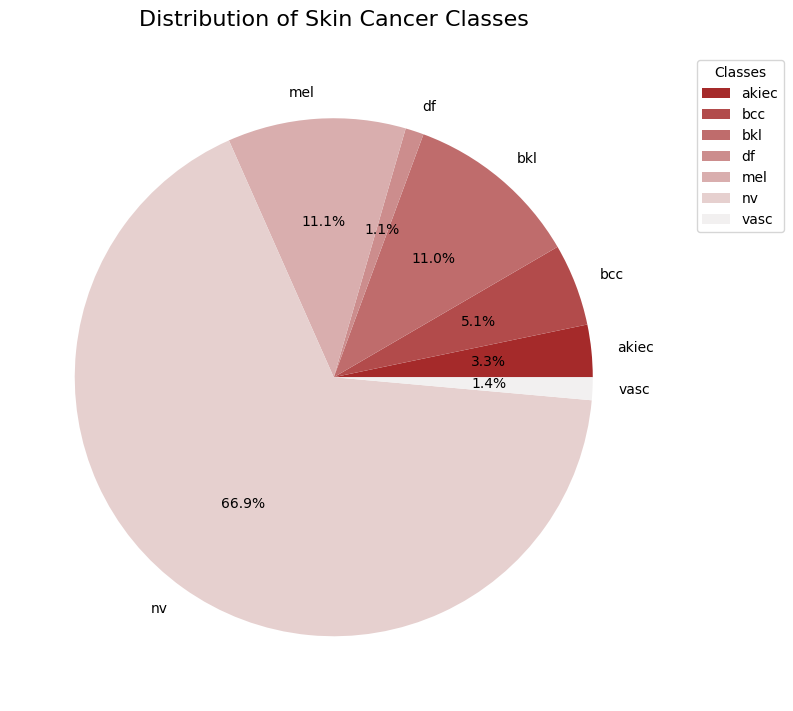

In [19]:
# Generate a lighter brown color palette
lighter_brown_colors = sns.light_palette("brown", n_colors=len(unique_vals), reverse=True)

# Plot the distribution of skin cancer classes as a pie chart
fig, ax = plt.subplots(figsize=(8, 8))  
count.plot(
    kind='pie', 
    autopct='%1.1f%%',  
    colors=lighter_brown_colors, 
    legend=True,  
    ax=ax  
)

# Enhance the plot aesthetics
ax.set_ylabel('') 
ax.set_title('Distribution of Skin Cancer Classes', fontsize=16, pad=20) 

# Adjust the legend position for better visibility
ax.legend(
    title='Classes', 
    bbox_to_anchor=(1.05, 1),  
    loc='upper left'  
)

# Display the pie chart
plt.tight_layout()  
plt.show()

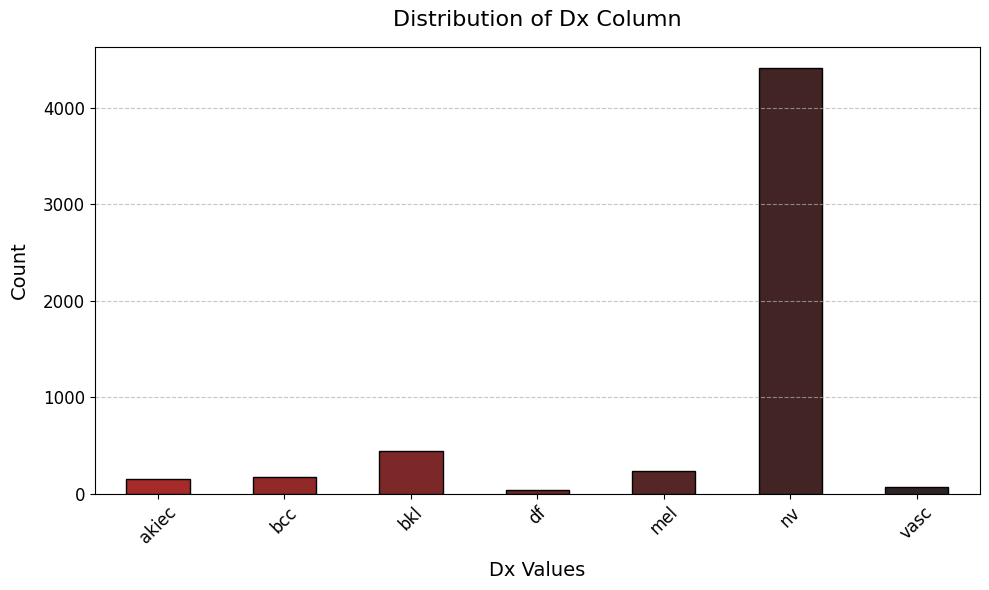

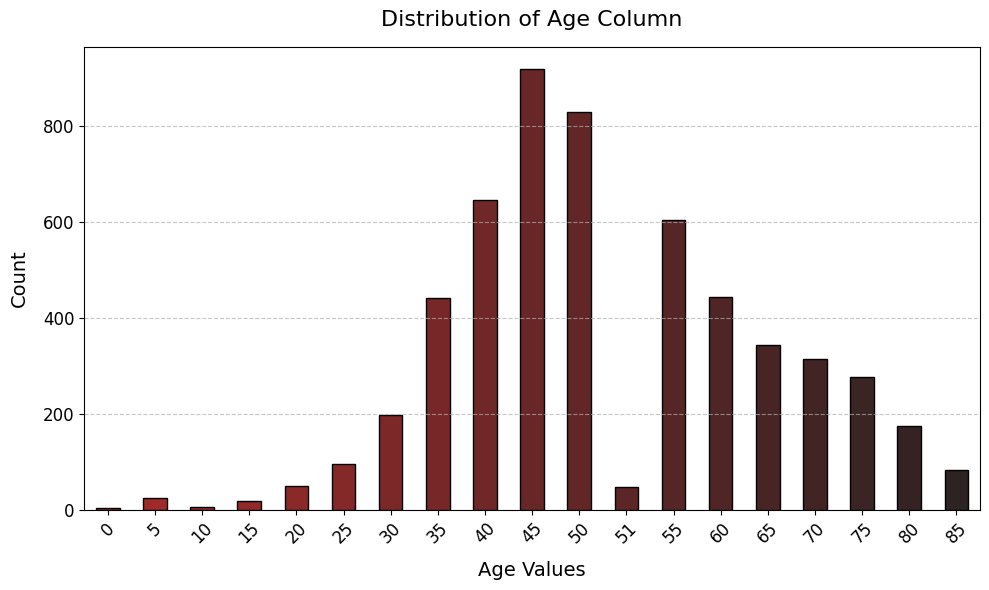

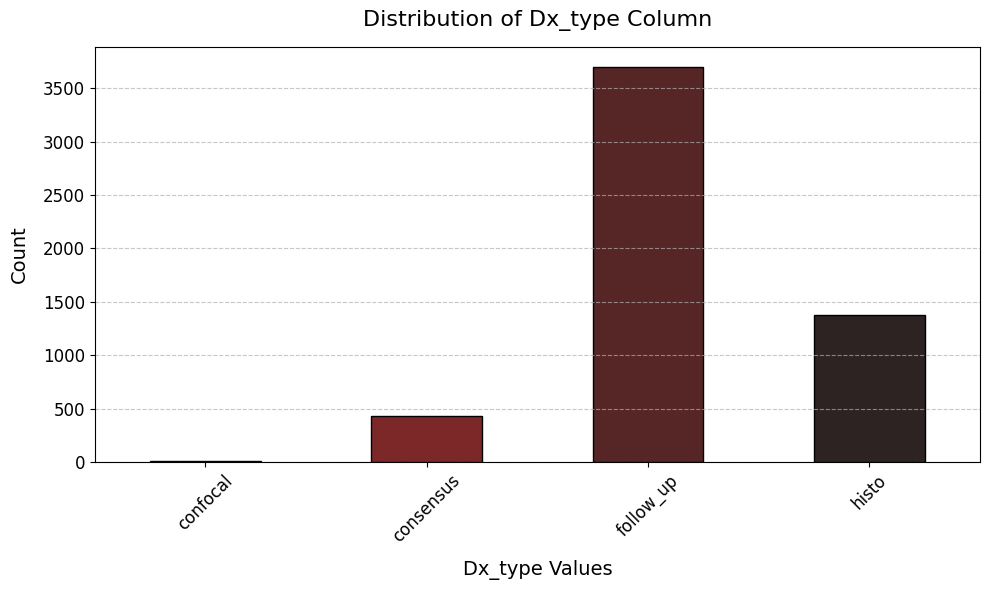

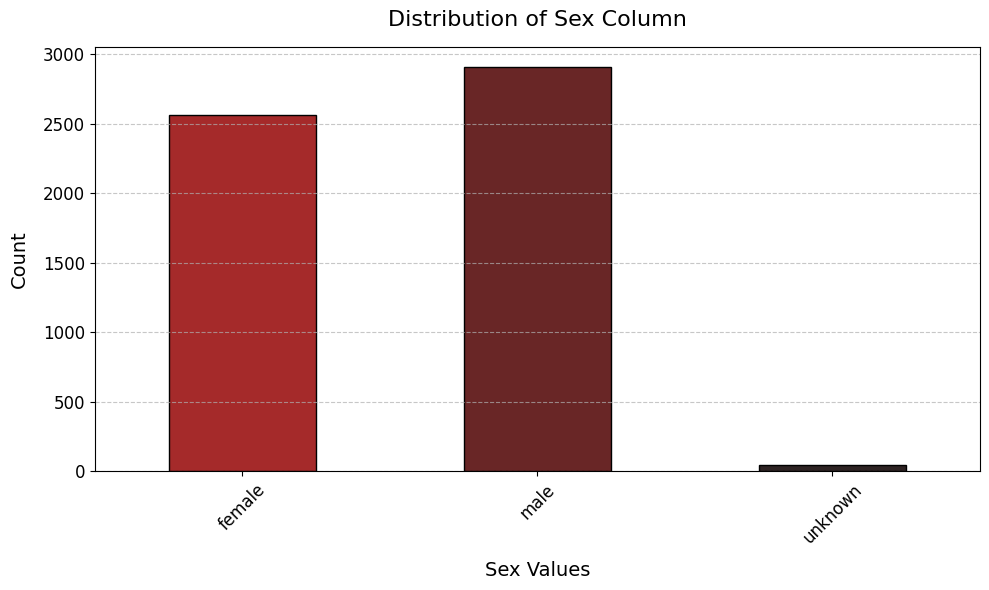

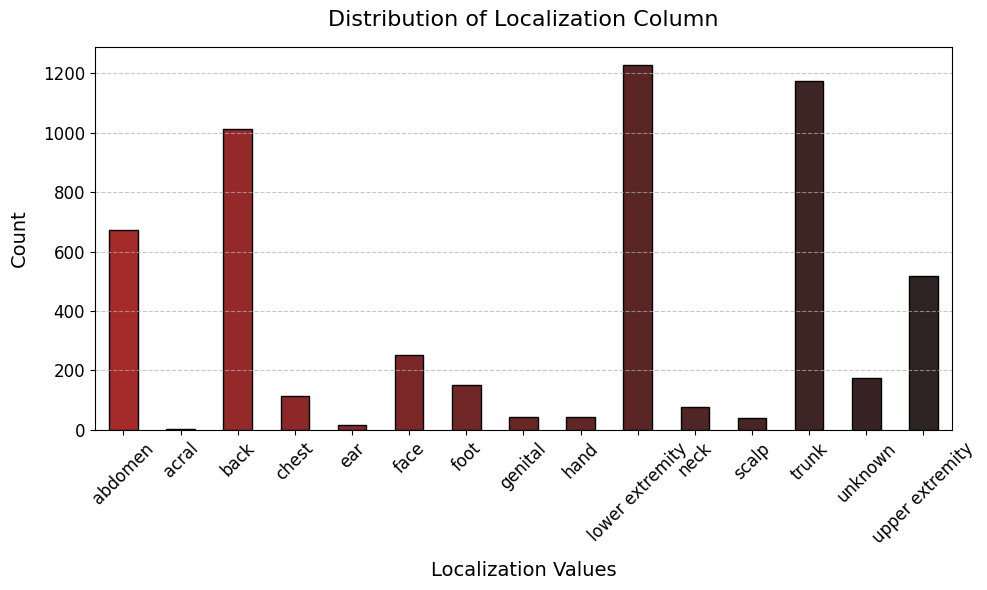

In [20]:
# Define columns to explore
columns_exp = ['dx', 'age', 'dx_type', 'sex', 'localization']

# Iterate through each column to visualize its distribution
for column in columns_exp:
  # Count occurrences of each unique value in the column
  count = metadata[column].value_counts().sort_index()

  # Extract unique values for the column
  unique_vals = count.index

  # Use the dark brown color palette for better visuals
  colors = sns.dark_palette("brown", n_colors=len(unique_vals), reverse=True)

  # Plot the distribution as a bar chart
  fig, ax = plt.subplots(figsize=(10, 6))
  count.plot(kind='bar', color=colors, edgecolor='black', ax=ax)

  # Set plot labels and title
  ax.set_xlabel(f'{column.capitalize()} Values', fontsize=14, labelpad=10)
  ax.set_ylabel('Count', fontsize=14, labelpad=10)
  ax.set_title(f'Distribution of {column.capitalize()} Column', fontsize=16, pad=15)

  # Rotate x-axis labels for better readability
  ax.tick_params(axis='x', rotation=45, labelsize=12)
  ax.tick_params(axis='y', labelsize=12)

  # Add gridlines for better readability
  ax.grid(axis='y', linestyle='--', alpha=0.7)

  # Adjust layout and display the plot
  plt.tight_layout()
  plt.show()

In [21]:
# Check for rows where the 'sex' column has the value 'unknown'
# This helps identify the number of entries with missing or unspecified gender information
unknown_sex_count = metadata.loc[metadata['sex'] == 'unknown'].shape

# Log the result for better understanding
print(f"Number of entries with 'unknown' sex: {unknown_sex_count[0]}")

Number of entries with 'unknown' sex: 45


In [22]:
# Check the number of rows where the 'localization' column has the value 'unknown'
# This helps identify entries with missing or unspecified localization information
unknown_localization_count = metadata.loc[metadata['localization'] == 'unknown'].shape

# Log the result for better understanding
print(f"Number of entries with 'unknown' localization: {unknown_localization_count[0]}")

Number of entries with 'unknown' localization: 173


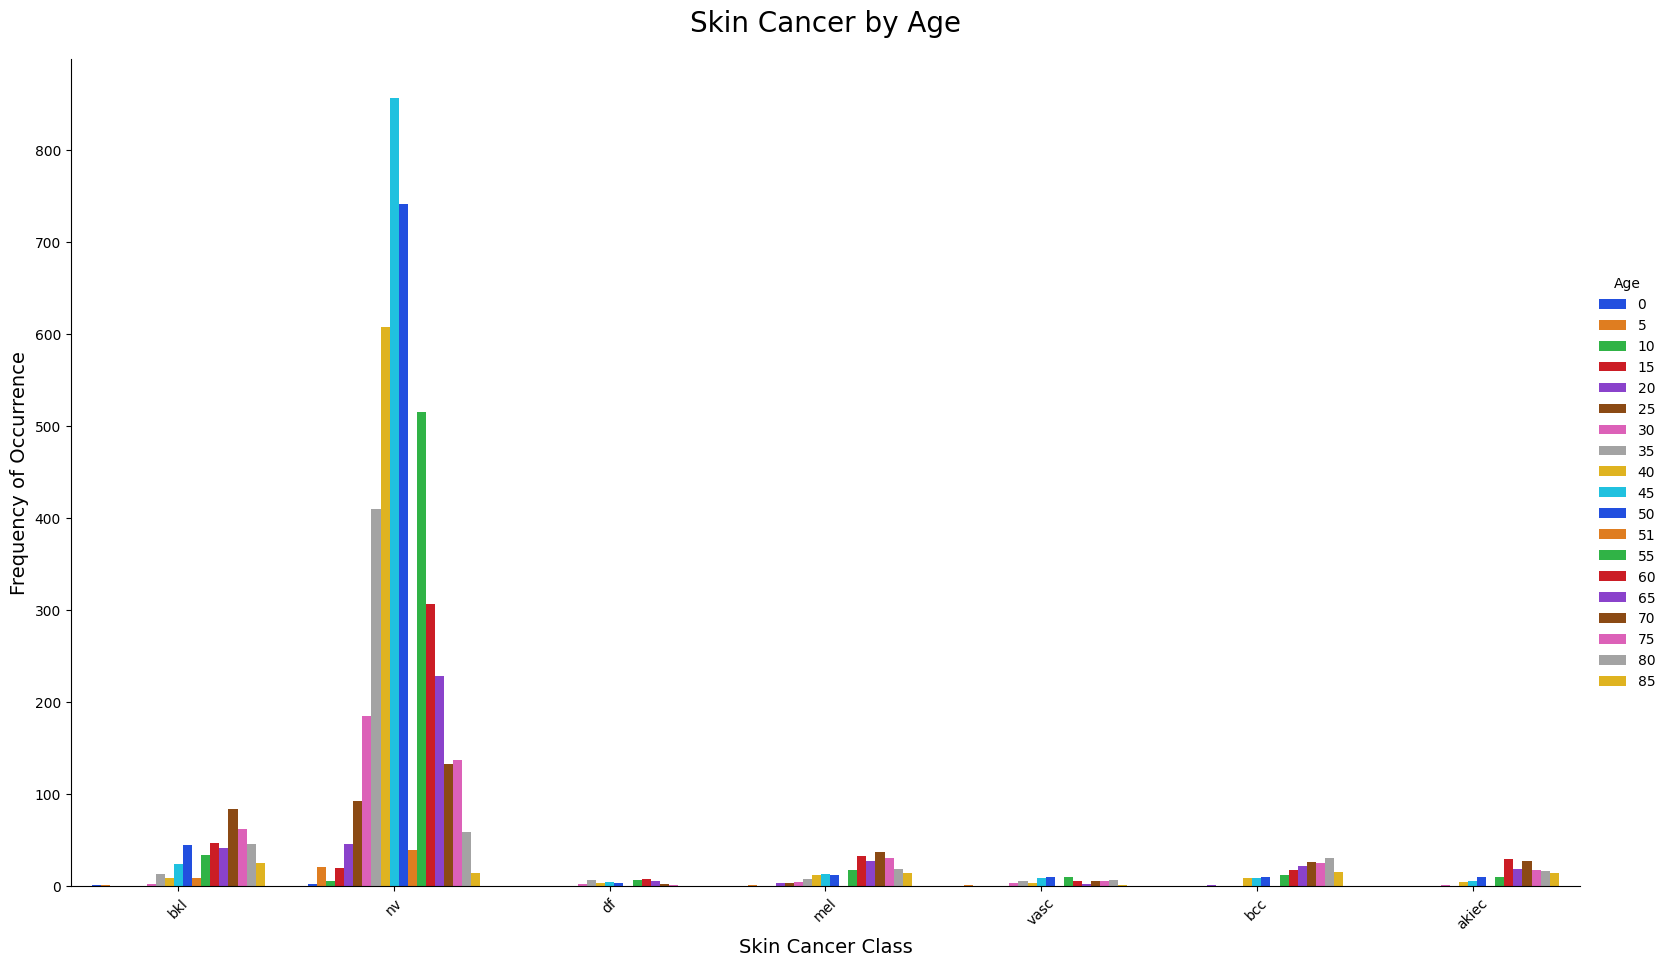

In [23]:
# Visualizing the distribution of skin cancer classes by age
# Using a categorical plot to show the count of each skin cancer class, grouped by age

# Create a categorical plot with 'dx' on the x-axis and 'age' as the hue
catplot = sns.catplot(
    data=metadata,
    x="dx",                # Skin cancer class
    kind="count",          # Count plot to show frequency
    hue="age",             # Group by age
    palette="bright",      # Use a bright color palette for better distinction
    height=9,              # Set figure height
    aspect=16/9            # Set aspect ratio for better readability
)

# Customize plot aesthetics
catplot.ax.set_title("Skin Cancer by Age", fontsize=20, pad=20)  
catplot.set_axis_labels("Skin Cancer Class", "Frequency of Occurrence", fontsize=14) 
catplot._legend.set_title("Age") 
catplot.ax.tick_params(axis="x", rotation=45) 


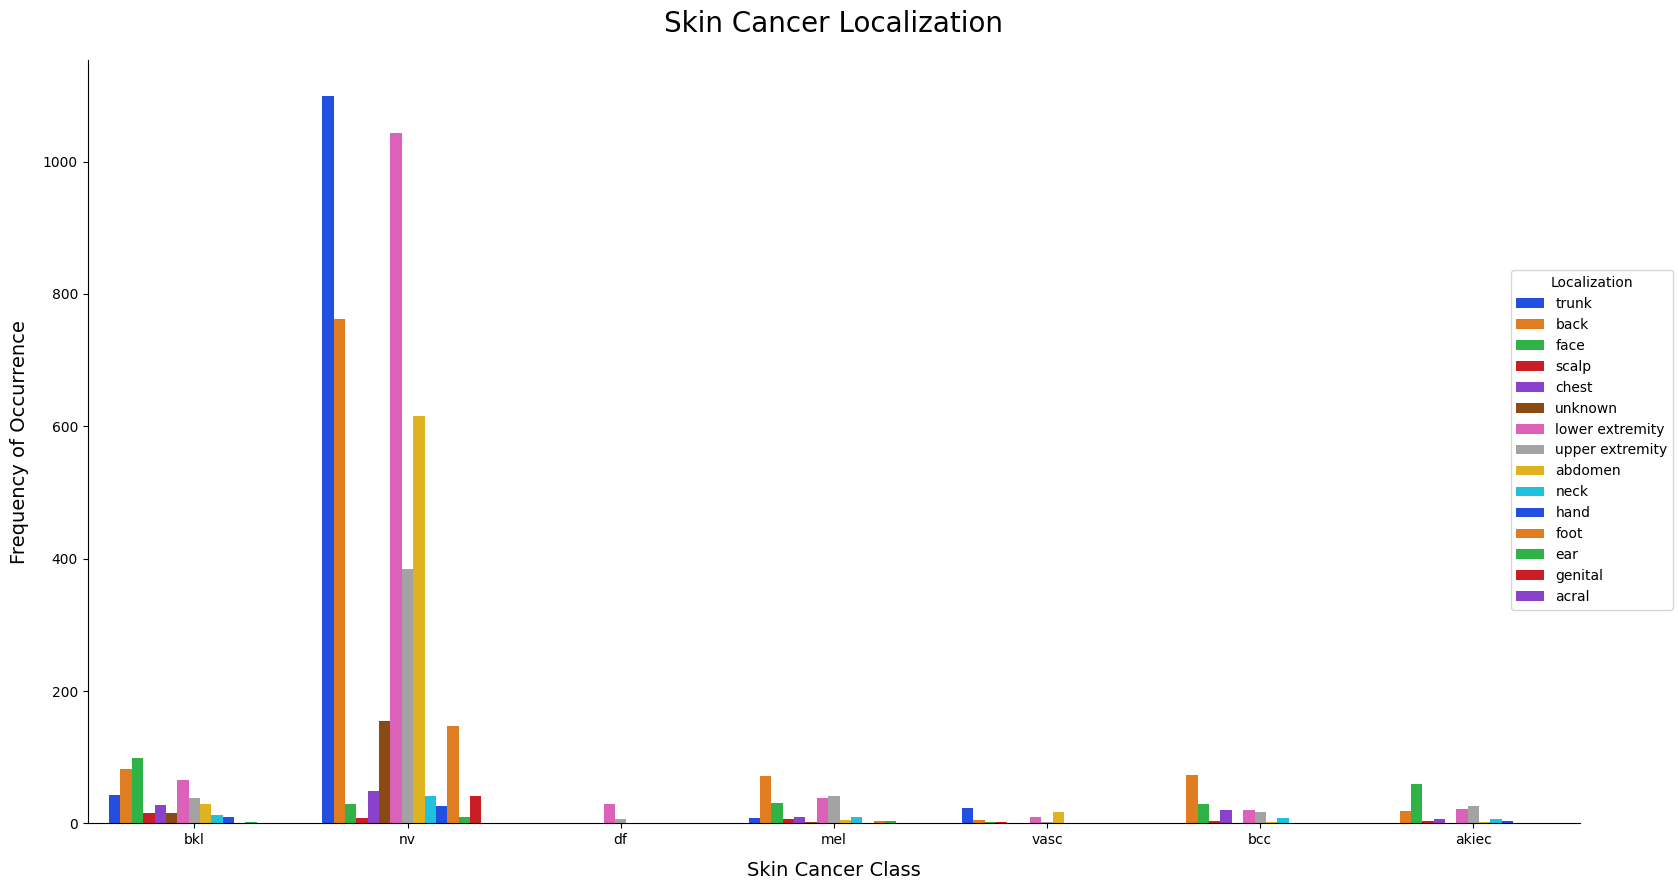

In [24]:
# Create a categorical plot for skin cancer localization
g = sns.catplot(
    x="dx", 
    kind="count", 
    hue="localization", 
    palette='bright', 
    data=metadata
)

# Set the figure size for better readability
g.fig.set_size_inches(16, 9)

# Center the title and improve its formatting
g.ax.set_title(
    'Skin Cancer Localization', 
    fontsize=20, 
    pad=20, 
    loc='center'
)

# Set axis labels with improved formatting
g.set_xlabels('Skin Cancer Class', fontsize=14, labelpad=10)
g.set_ylabels('Frequency of Occurrence', fontsize=14, labelpad=10)

# Set the legend title and position it outside the plot for better visibility
g._legend.set_title('Localization')
g._legend.set_bbox_to_anchor((1.05, .5)) 
g._legend.set_frame_on(True)  

# Adjust layout to prevent overlapping
plt.tight_layout()

In [25]:
# Display the first few rows of the metadata DataFrame after all updates
metadata.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization,dup_les,image_path
10,HAM_0001396,ISIC_0025276,bkl,histo,55,female,trunk,False,/home/asad/Thesis Practical part/dataset/HAM10...
15,HAM_0007207,ISIC_0031326,bkl,histo,65,male,back,False,/home/asad/Thesis Practical part/dataset/HAM10...
20,HAM_0006071,ISIC_0032343,bkl,histo,70,female,face,False,/home/asad/Thesis Practical part/dataset/HAM10...
33,HAM_0005612,ISIC_0024981,bkl,histo,80,male,scalp,False,/home/asad/Thesis Practical part/dataset/HAM10...
34,HAM_0005388,ISIC_0027815,bkl,histo,80,male,chest,False,/home/asad/Thesis Practical part/dataset/HAM10...


**PLOT IMAGES FROM EACH CLASS AND THEIR COLOR DISTRIBUTIONS**

In [26]:
def pltImg(images, labels, row_num, col_num):
    """
    Display a grid of images with their corresponding labels and mean intensity.

    Parameters:
    images (list): List of image objects to display.
    labels (list): List of labels corresponding to the images.
    row_num (int): Number of rows in the grid.
    col_num (int): Number of columns in the grid.

    Returns:
    None
    """
    # Create a grid of subplots
    fig, axes = plt.subplots(row_num, col_num, figsize=(15, 8))
    axes = axes.ravel()  # Flatten the 2D array of axes into a 1D array for easy iteration

    # Iterate through the images and display them
    for i, image in enumerate(images):
        axes[i].imshow(image) 
        axes[i].axis('off')  
        # Set the title with the class label and mean intensity of the image
        axes[i].set_title(f"Class: {labels[i]}\nMean intensity: {np.mean(image):.1f}")

    # Adjust layout to prevent overlapping
    plt.tight_layout()
    plt.show()


def pltHist(images, labels, row_num, col_num):
    """
    Display histograms of color channel distributions for a grid of images.

    Parameters:
    images (list): List of image objects to analyze.
    labels (list): List of labels corresponding to the images.
    row_num (int): Number of rows in the grid.
    col_num (int): Number of columns in the grid.

    Returns:
    None
    """
    # Create a grid of subplots
    fig, axes = plt.subplots(row_num, col_num, figsize=(15, 8))
    axes = axes.ravel()  # Flatten the 2D array of axes into a 1D array for easy iteration

    # Define colors for RGB channels
    colors = ["red", "green", "blue"]

    # Iterate through the images and plot their histograms
    for i, image in enumerate(images):
        image_array = np.array(image)  

        # Plot histograms for each color channel
        for channel in range(3):
            hist, bin_edges = np.histogram(
                image_array[:, :, channel], bins=256, range=(0, 256)
            )
            axes[i].plot(bin_edges[:-1], hist, color=colors[channel]) 

        axes[i].set_title(f"Class: {labels[i]}")

    # Adjust layout to prevent overlapping
    plt.tight_layout()
    plt.show()


In [27]:
def randImg(df, label, seed, sample_size):
    """
    Randomly samples images from a specific class in the dataset.

    Parameters:
    df (pd.DataFrame): The DataFrame containing metadata, including image paths and labels.
    label (str): The class label to filter and sample images from.
    seed (int): The random seed for reproducibility.
    sample_size (int): The number of images to sample.

    Returns:
    tuple: A tuple containing two lists:
        - images (list): List of sampled image objects.
        - labels (list): List of corresponding labels for the sampled images.
    """
    # Filter the DataFrame to include only rows with the specified class label
    df_class = df[df['dx'] == label]

    # Ensure reproducibility by setting the random seed
    random.seed(seed)

    # Randomly sample the specified number of rows from the filtered DataFrame
    sample_df = df_class.sample(n=sample_size)

    # Initialize lists to store the sampled images and their corresponding labels
    images = []
    labels = []

    # Iterate through the sampled rows to load images
    for _, row in sample_df.iterrows():
        image_path = row['image_path'] 

        # Check if the image file exists at the specified path
        if os.path.exists(image_path):
            image = Image.open(image_path)
            images.append(image)

            labels.append(label)
        else:
            print(f"Warning: Image not found at path: {image_path}")

    # Return the lists of images and labels as a tuple
    return images, labels


--- Showcasing examples for class: bkl ---



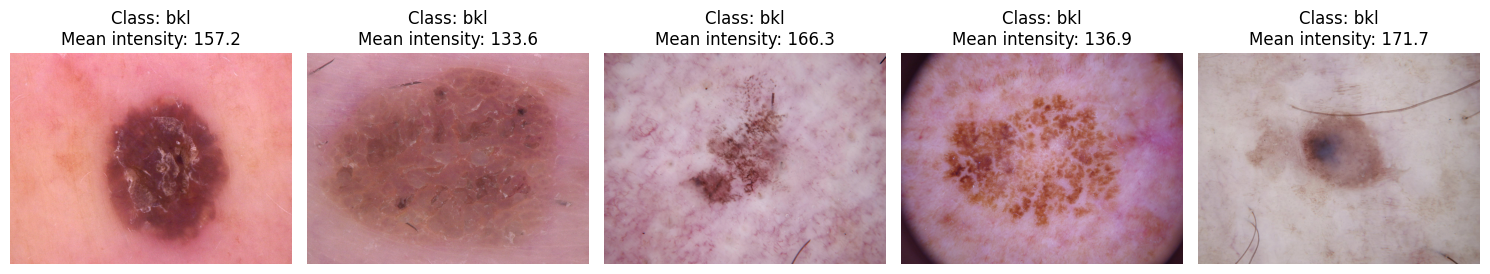

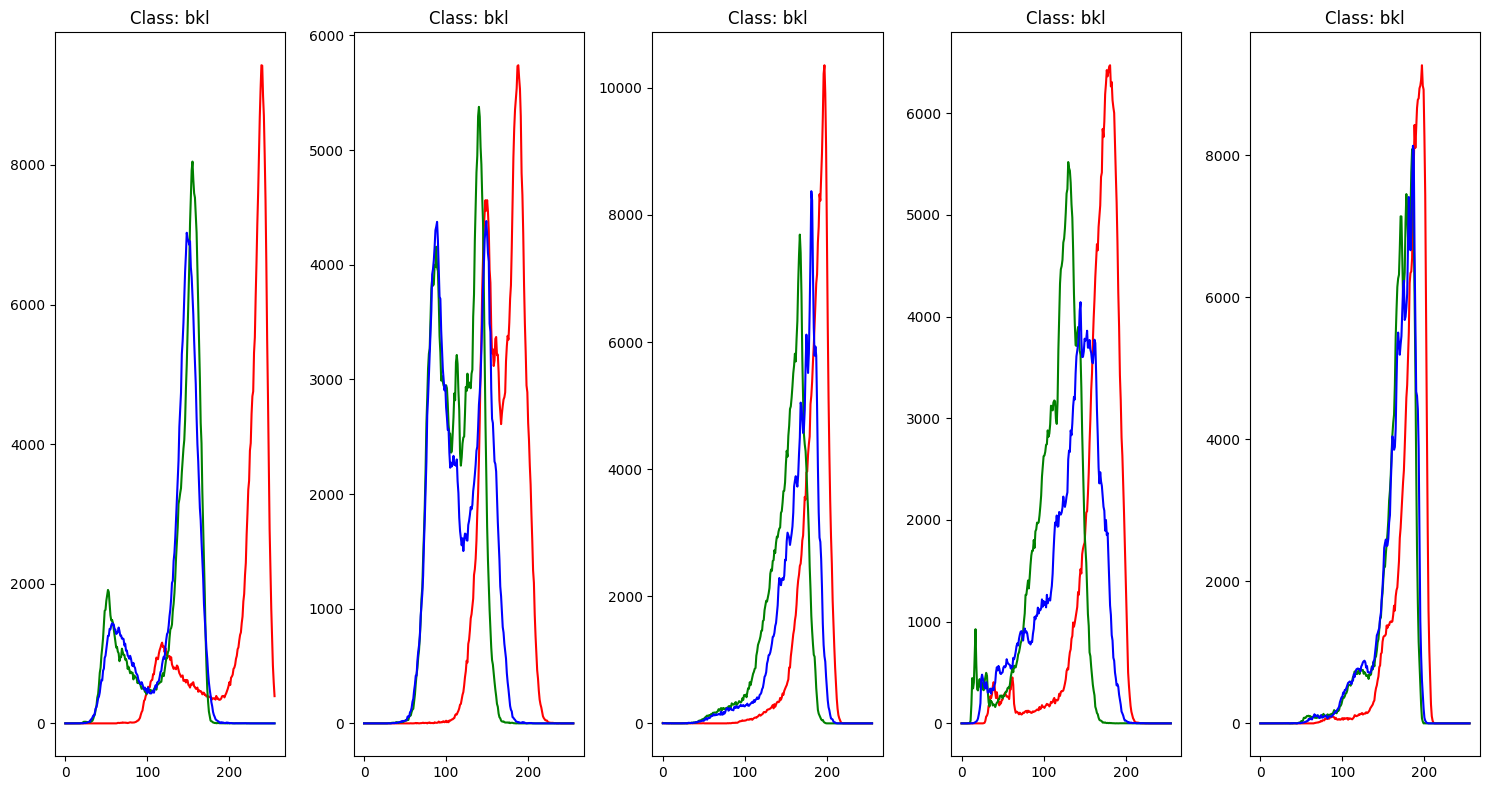


--- Showcasing examples for class: nv ---



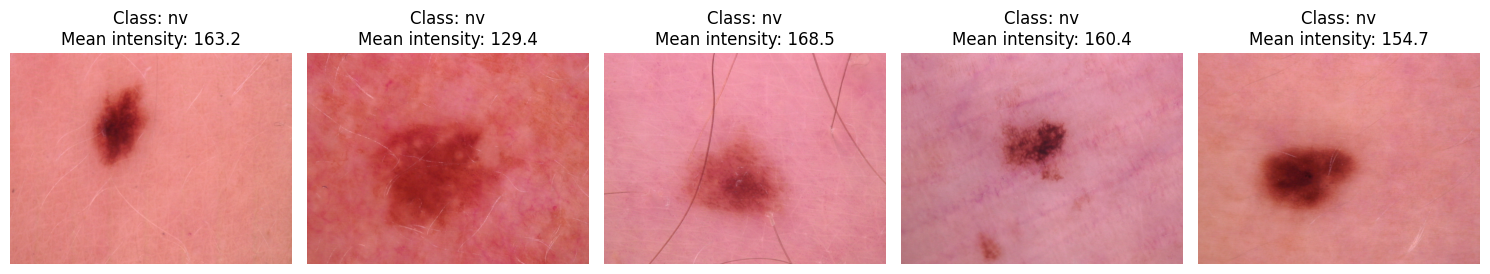

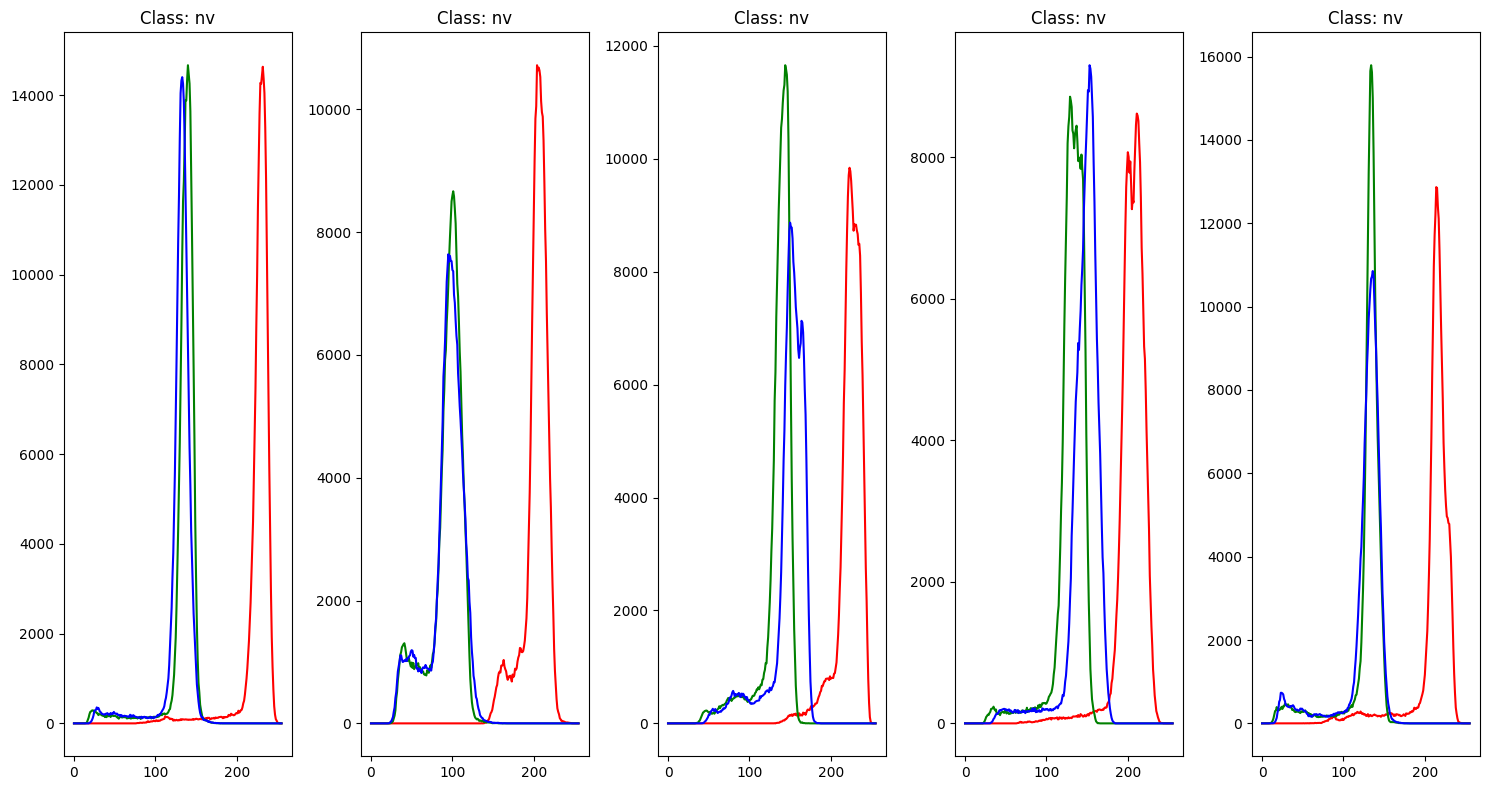


--- Showcasing examples for class: df ---



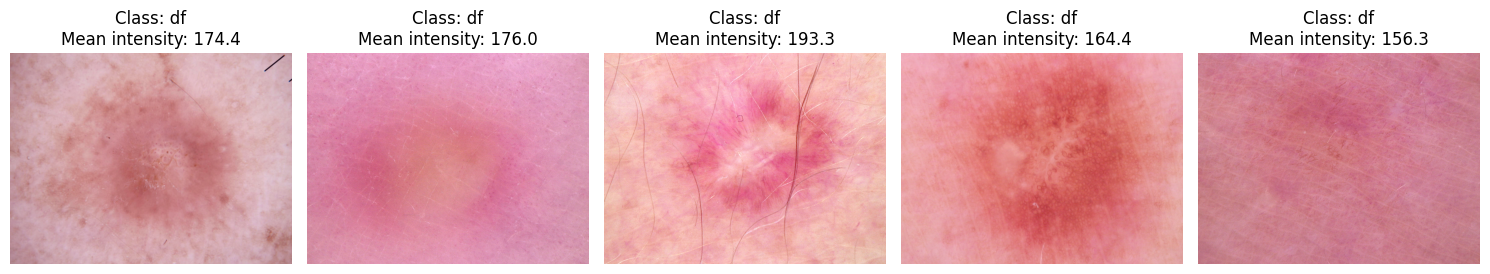

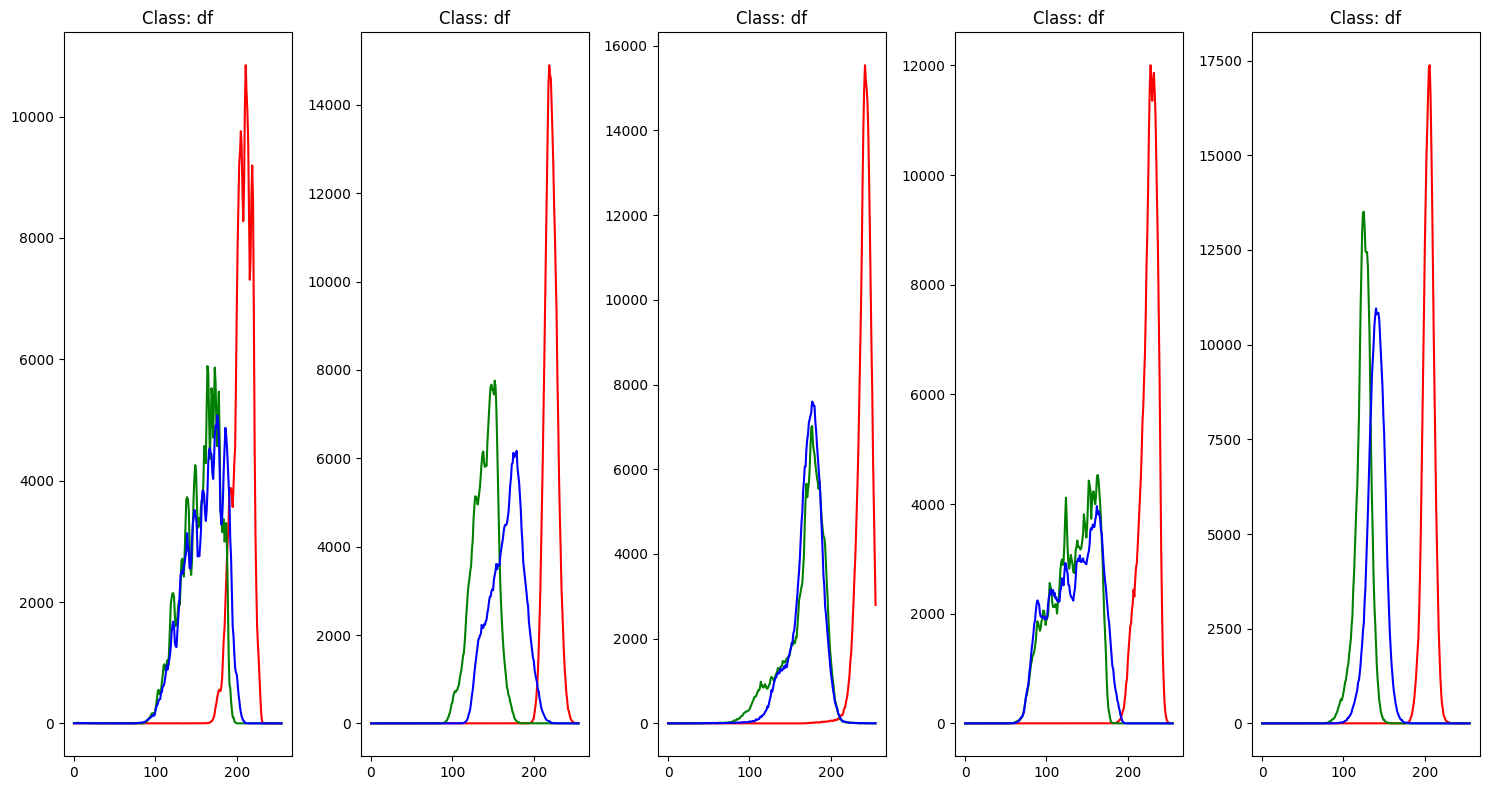


--- Showcasing examples for class: mel ---



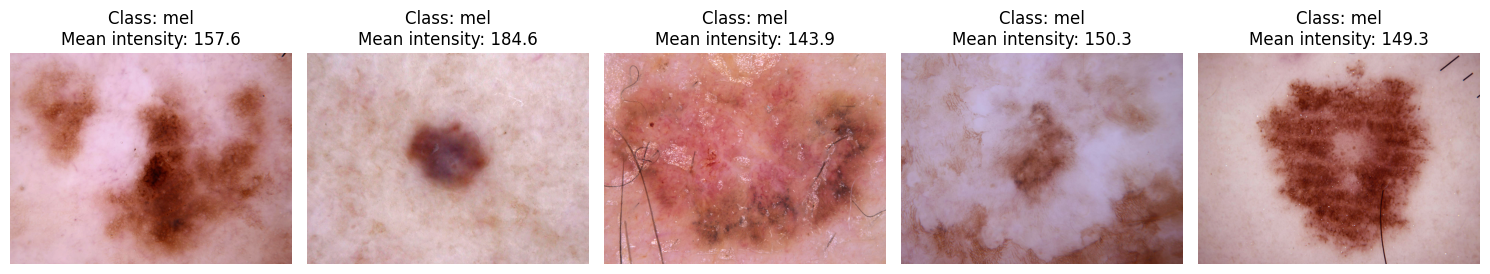

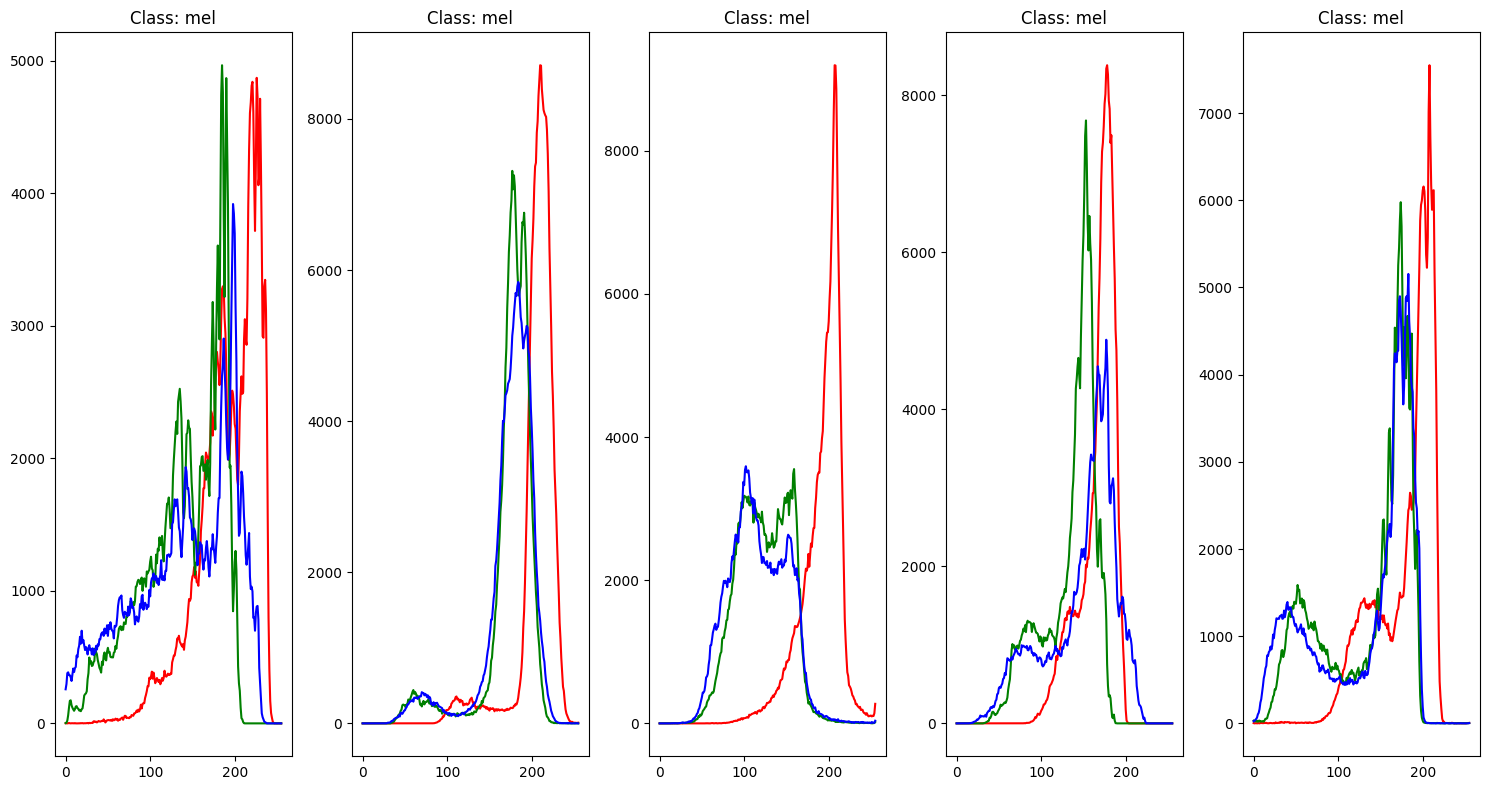


--- Showcasing examples for class: vasc ---



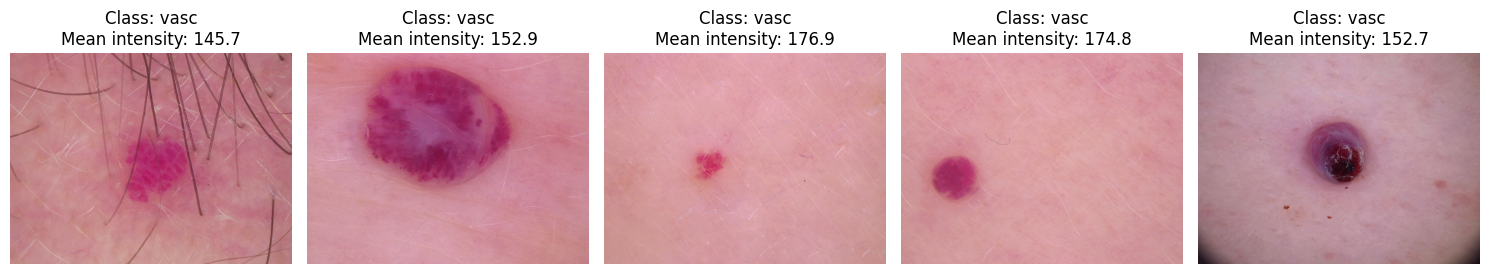

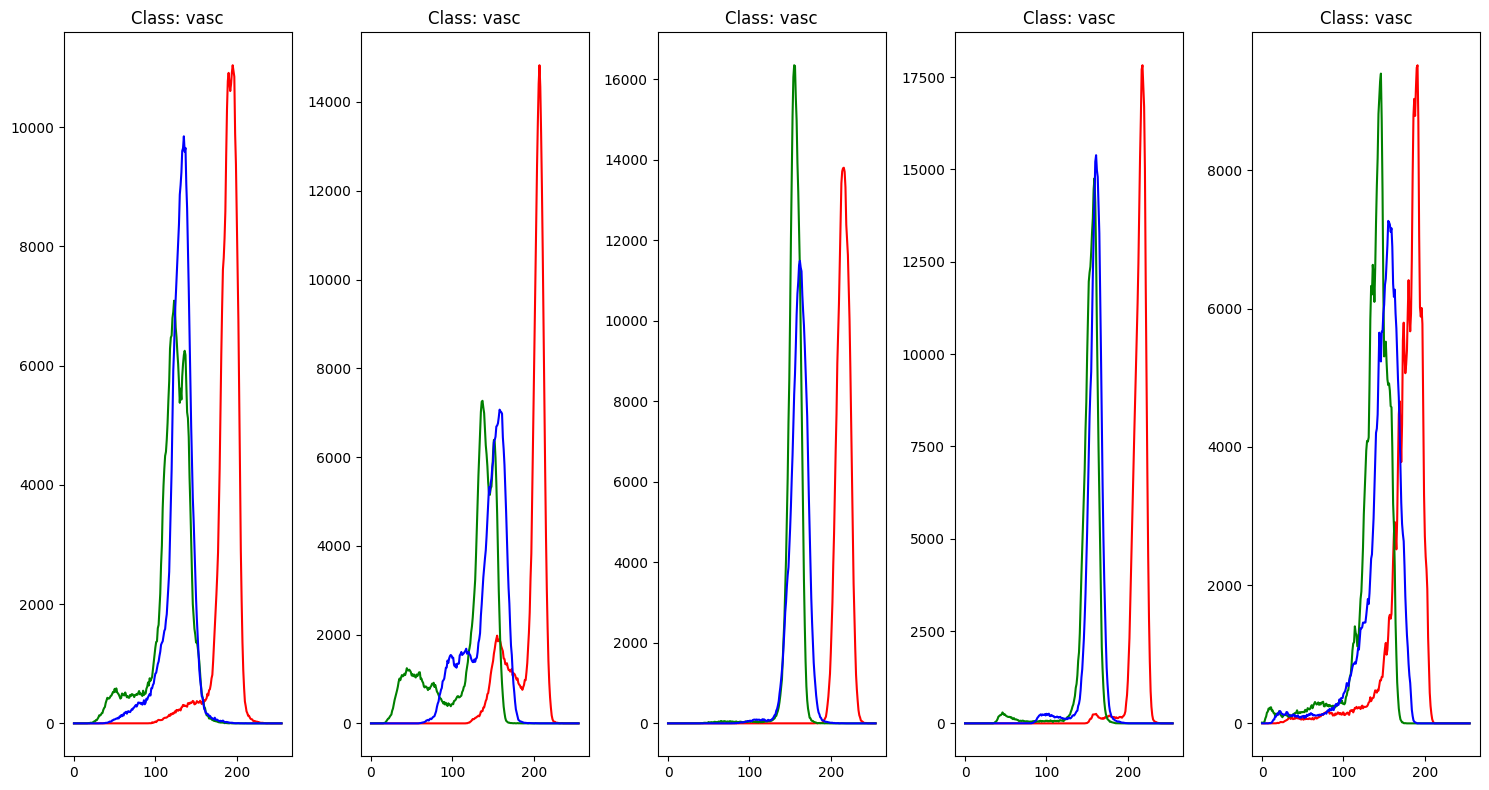


--- Showcasing examples for class: bcc ---



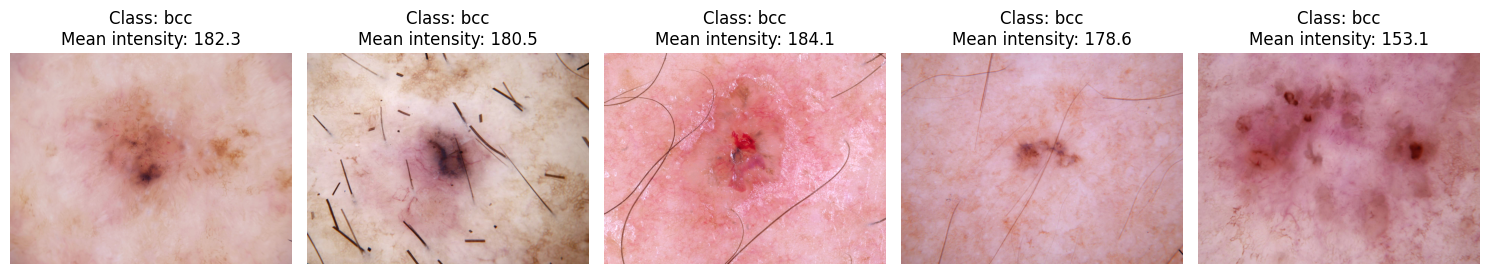

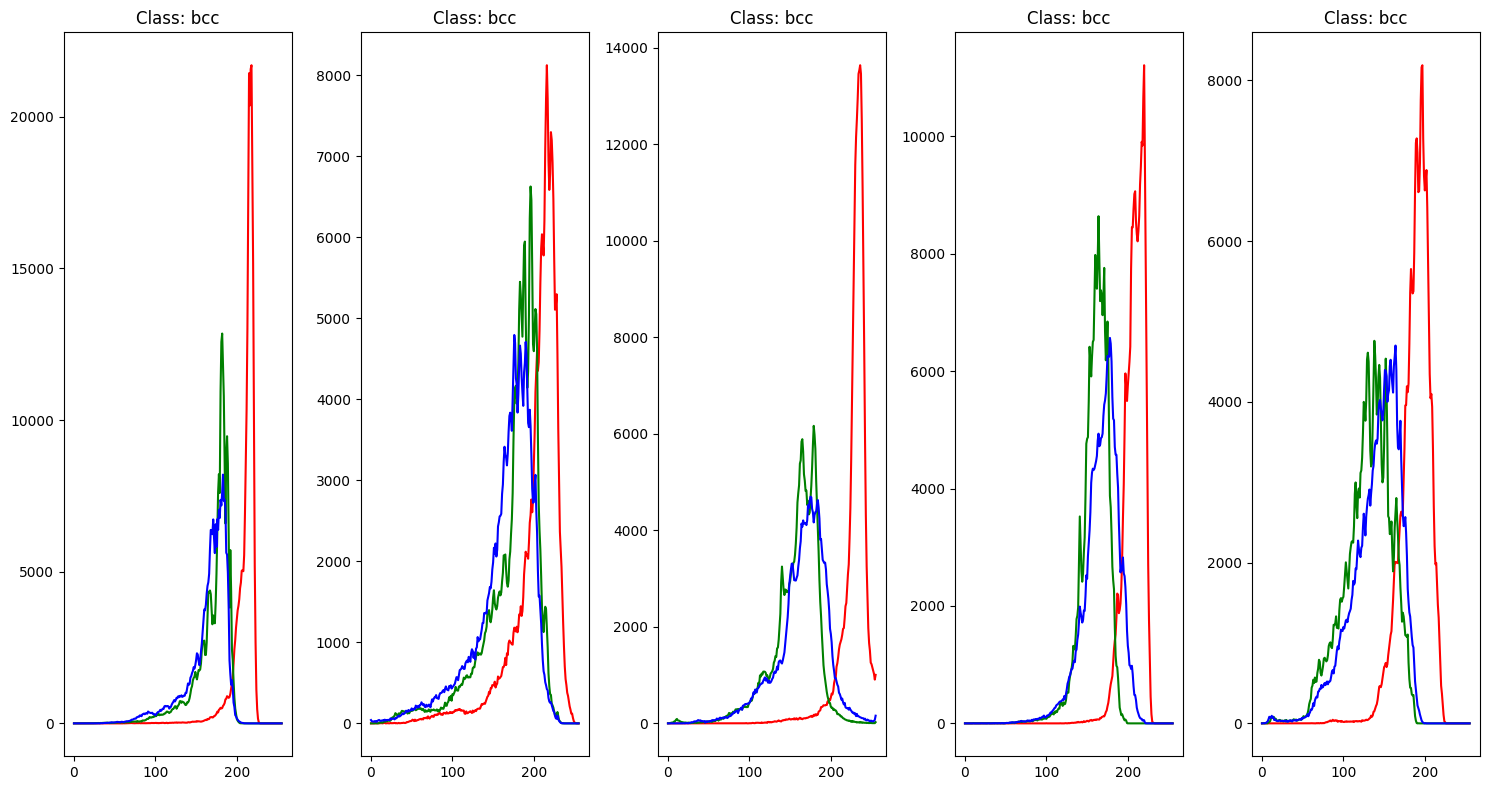


--- Showcasing examples for class: akiec ---



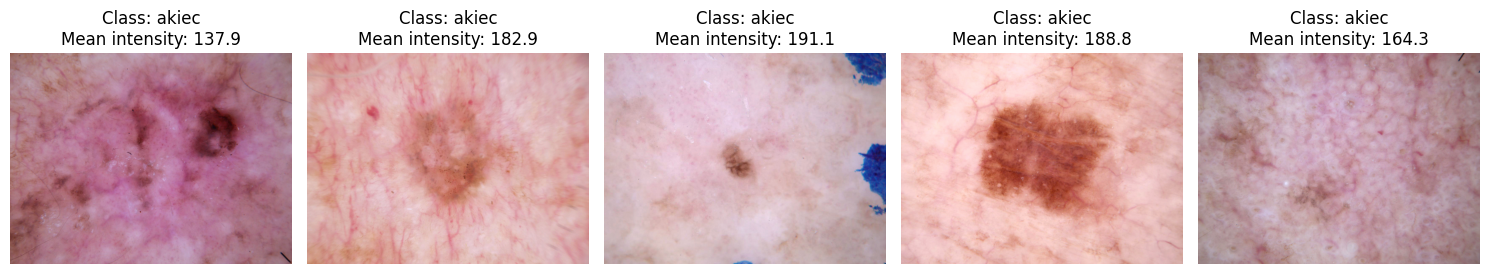

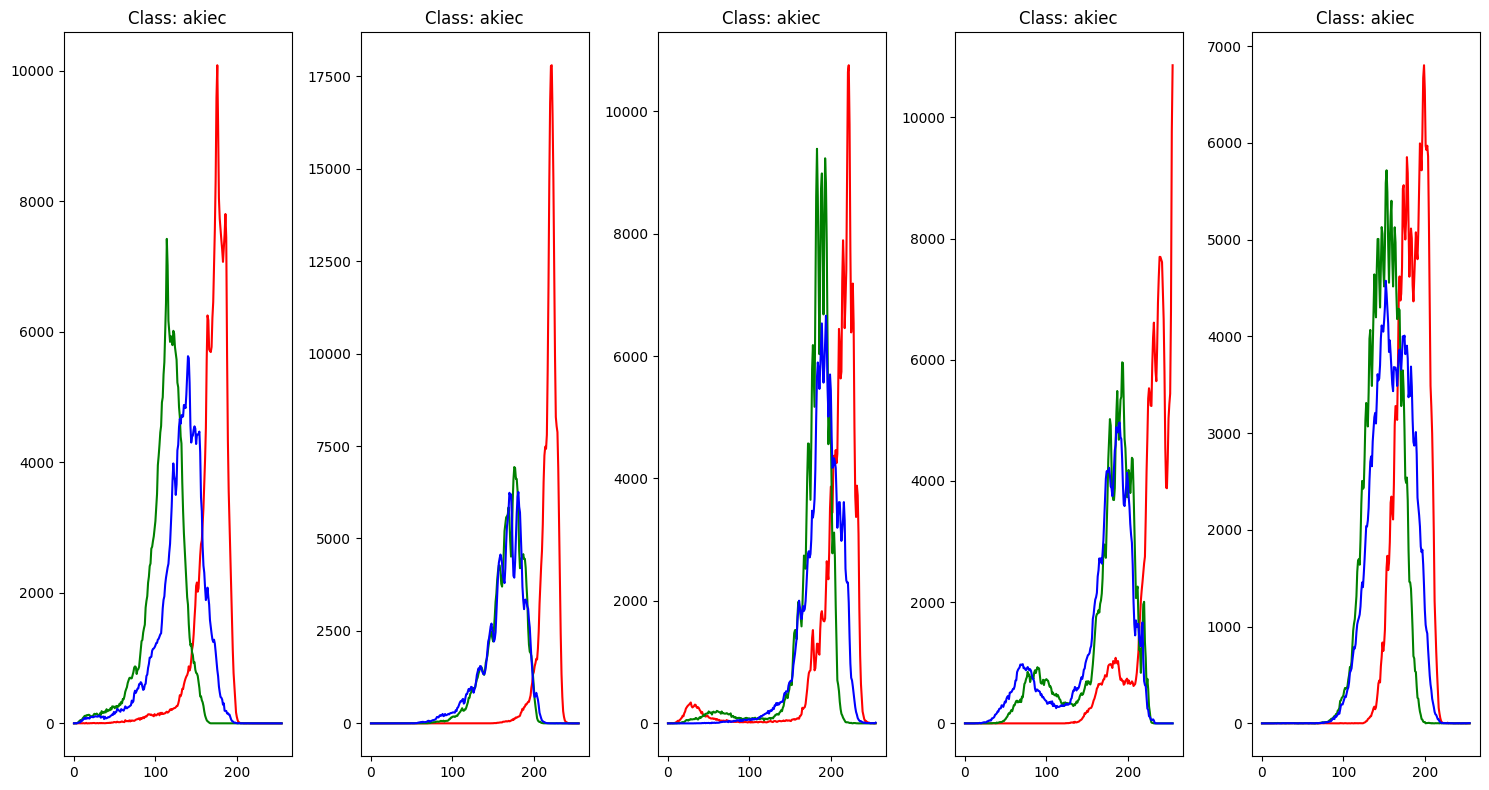

In [28]:
# Define the list of class labels to iterate through
class_labels = ['bkl', 'nv', 'df', 'mel', 'vasc', 'bcc', 'akiec']

# Iterate over each class label to showcase examples
for class_label in class_labels:
    print(f"\n--- Showcasing examples for class: {class_label} ---\n")
    
    # Randomly sample images and their corresponding labels for the current class
    images, labels = randImg(
        df=metadata,      
        label=class_label,
        seed=42,          
        sample_size=5     
    )

    # Display the sampled images in a grid format
    pltImg(
        images=images,     
        labels=labels,     
        row_num=1,         
        col_num=5          
    )

    # Display histograms of color channel distributions for the sampled images
    pltHist(
        images=images,     
        labels=labels,     
        row_num=1,         
        col_num=5          
    )


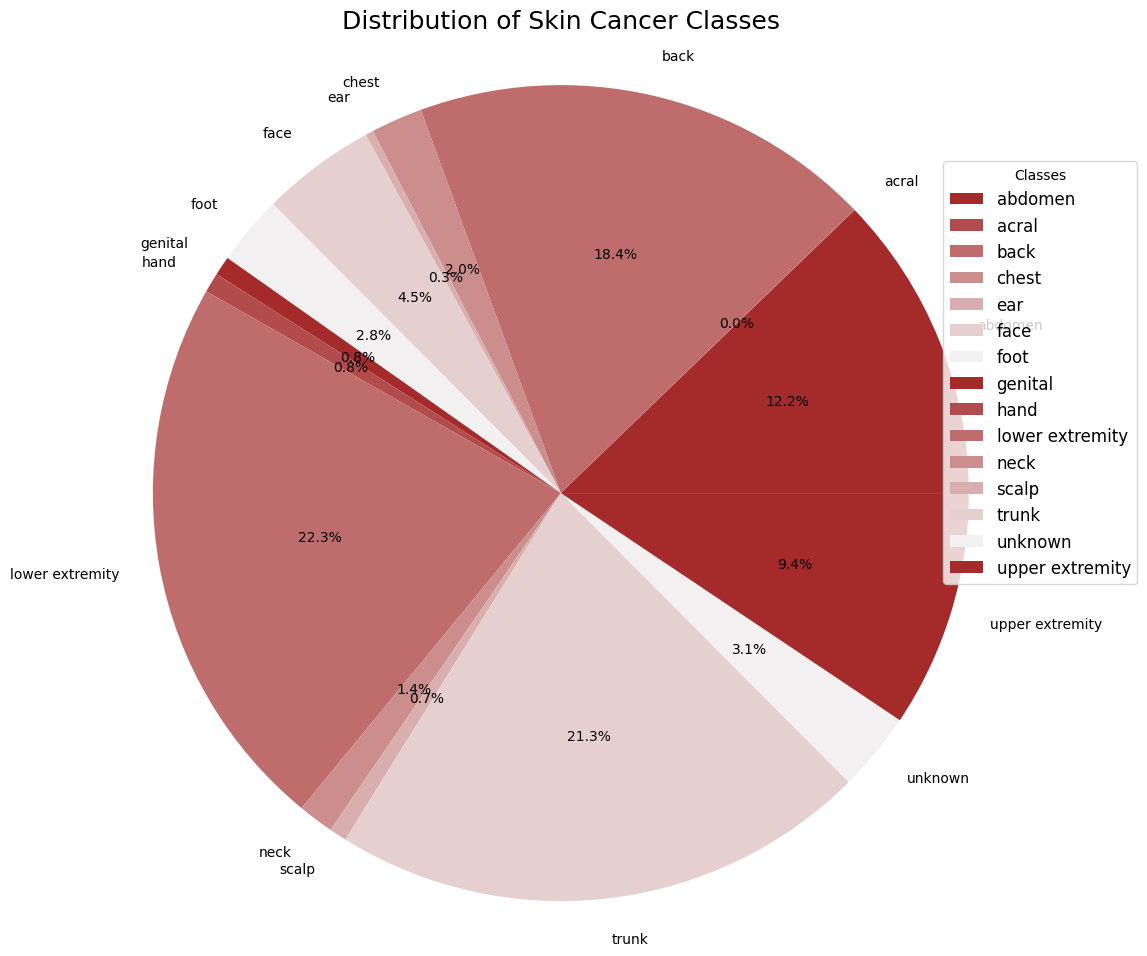

In [29]:
# Plot the distribution of skin cancer classes as a pie chart
fig, ax = plt.subplots(figsize=(12, 12))  # Set figure size for better readability

# Use the brown color spectrum for the pie chart
count.plot(
    kind="pie", 
    autopct='%1.1f%%', 
    colors=lighter_brown_colors, 
    legend=True, 
    radius=1.5,  
    ax=ax  
)

# Enhance the plot aesthetics
ax.set_ylabel('')  
ax.set_title('Distribution of Skin Cancer Classes', fontsize=18, pad=90)

# Adjust the legend position and formatting for better visibility
ax.legend(
    title='Classes',  
    bbox_to_anchor=(1.05, 1), 
    loc='upper left', 
    fontsize=12
)

# Display the pie chart
plt.tight_layout()  
plt.show()

**I am facing massive data imbalance as pie chart show that we have to solve**

In [30]:
# Convert the count Series to a DataFrame for better readability
count_df = count.reset_index()
count_df.columns = ['Skin Cancer Class', 'Count']

# Display the DataFrame
print(count_df)

   Skin Cancer Class  Count
0            abdomen    673
1              acral      1
2               back   1012
3              chest    113
4                ear     17
5               face    250
6               foot    152
7            genital     42
8               hand     43
9    lower extremity   1228
10              neck     78
11             scalp     38
12             trunk   1176
13           unknown    173
14   upper extremity    518


| Label | Full Name                          | Description                                                                                     | Images |
|-------|------------------------------------|-------------------------------------------------------------------------------------------------|--------|
| nv    | Melanocytic nevi                  | Benign melanocyte neoplasms with various dermatoscopic appearances.                            | 4415   |
| mel   | Melanoma                          | Malignant melanocyte neoplasms, invasive or in situ, curable if excised early.                 | 230    |
| bkl   | Benign keratosis-like lesions     | Includes seborrheic keratoses, solar lentigo, and lichen-planus-like keratoses.                | 440    |
| bcc   | Basal cell carcinoma              | Common epithelial skin cancer, rarely metastasizes but grows destructively if untreated.       | 175    |
| akiec | Actinic keratoses / Bowen's disease | Precursors to squamous cell carcinoma, often UV-induced, treatable locally.                    | 151    |
| vasc  | Vascular lesions                  | Includes cherry angiomas, angiokeratomas, and pyogenic granulomas.                             | 64     |
| df    | Dermatofibroma                    | Benign skin lesion, often a reaction to minor trauma, with a central fibrosis zone.            | 39     |

**Total Images:** 5514


**DATA AUGMENTATION**

In [31]:
# Get unique values from the 'dx' column, sort them, and format the output
unique_classes = sorted(metadata.dx.unique())
print("Unique Skin Cancer Classes in the Dataset:")
for class_name in unique_classes:
    print(f"- {class_name}")

Unique Skin Cancer Classes in the Dataset:
- akiec
- bcc
- bkl
- df
- mel
- nv
- vasc


In [32]:
# Convert the count Series to a DataFrame for better readability
count_df = count.reset_index()
count_df.columns = ['Skin Cancer Class', 'Count']

# Display the DataFrame in a tabular format
print("Distribution of Skin Cancer Classes:")
print(count_df.to_string(index=False))

Distribution of Skin Cancer Classes:
Skin Cancer Class  Count
          abdomen    673
            acral      1
             back   1012
            chest    113
              ear     17
             face    250
             foot    152
          genital     42
             hand     43
  lower extremity   1228
             neck     78
            scalp     38
            trunk   1176
          unknown    173
  upper extremity    518


**now lets solve the imbalance issue mentioned earlier after the pie chart analysis**

In [33]:
def data_aug(df, col_name, val_name, class_max):
  """
  Balances the dataset by oversampling the minority class to match the majority class.

  Parameters:
  df (pd.DataFrame): The DataFrame containing the data to balance.
  col_name (str): The column name representing the class labels.
  val_name (str): The name of the minority class to oversample.
  class_max (str): The name of the majority class to match.

  Returns:
  pd.DataFrame: The updated DataFrame with balanced classes.
  """
  # Filter rows for the specified classes (minority and majority)
  filtered_df = df[df[col_name].isin([val_name, class_max])]

  # Get the count of samples for each class
  class_counts = filtered_df[col_name].value_counts()
  majority_count = class_counts[class_max]
  minority_count = class_counts[val_name]

  # Separate the majority and minority class samples
  majority_class_samples = filtered_df[filtered_df[col_name] == class_max]
  minority_class_samples = filtered_df[filtered_df[col_name] == val_name]

  # Oversample the minority class to match the majority class count
  oversampled_minority_class = minority_class_samples.sample(
    n=majority_count, replace=True, random_state=42
  )

  # Remove the original minority class samples from the DataFrame
  df = df[df[col_name] != val_name]

  # Concatenate the oversampled minority class samples with the original DataFrame
  balanced_df = pd.concat([df, oversampled_minority_class], axis=0)

  # Return the balanced DataFrame
  return balanced_df

In [38]:
# Calculate the initial class counts
count = metadata['dx'].value_counts()

# Identify the class with the maximum count (majority class)
class_max = count.idxmax()

# Log the majority class for clarity
print(f"Majority Class: {class_max} with {count[class_max]} samples\n")

# Iterate through all unique classes in the dataset
for val_name in metadata['dx'].unique():
    # Skip the majority class as it does not need augmentation
    if val_name != class_max:
        # Log the current class being augmented
        current_count = count.get(val_name, 0)  # Use .get() to avoid KeyError
        print(f"Augmenting class: {val_name} (Current count: {current_count})")
        
        # Perform data augmentation for the current minority class
        metadata = data_aug(metadata, col_name='dx', val_name=val_name, class_max=class_max)
        
        # Recalculate the class counts after augmentation
        count = metadata['dx'].value_counts()
        
        # Log the updated count for the augmented class
        updated_count = count.get(val_name, 0)  # Use .get() to avoid KeyError
        print(f"Class {val_name} augmented to {updated_count} samples\n")

# Output the updated shape of the metadata DataFrame after balancing
print(f"Dataset balanced successfully!\n")
print(f"Updated Metadata Shape: {metadata.shape[0]} rows, {metadata.shape[1]} columns")

Majority Class: nv with 4415 samples

Augmenting class: bkl (Current count: 440)
Class bkl augmented to 4415 samples

Augmenting class: df (Current count: 39)
Class df augmented to 4415 samples

Augmenting class: mel (Current count: 230)
Class mel augmented to 4415 samples

Augmenting class: vasc (Current count: 64)
Class vasc augmented to 4415 samples

Augmenting class: bcc (Current count: 175)
Class bcc augmented to 4415 samples

Augmenting class: akiec (Current count: 151)
Class akiec augmented to 4415 samples

Dataset balanced successfully!

Updated Metadata Shape: 30905 rows, 9 columns


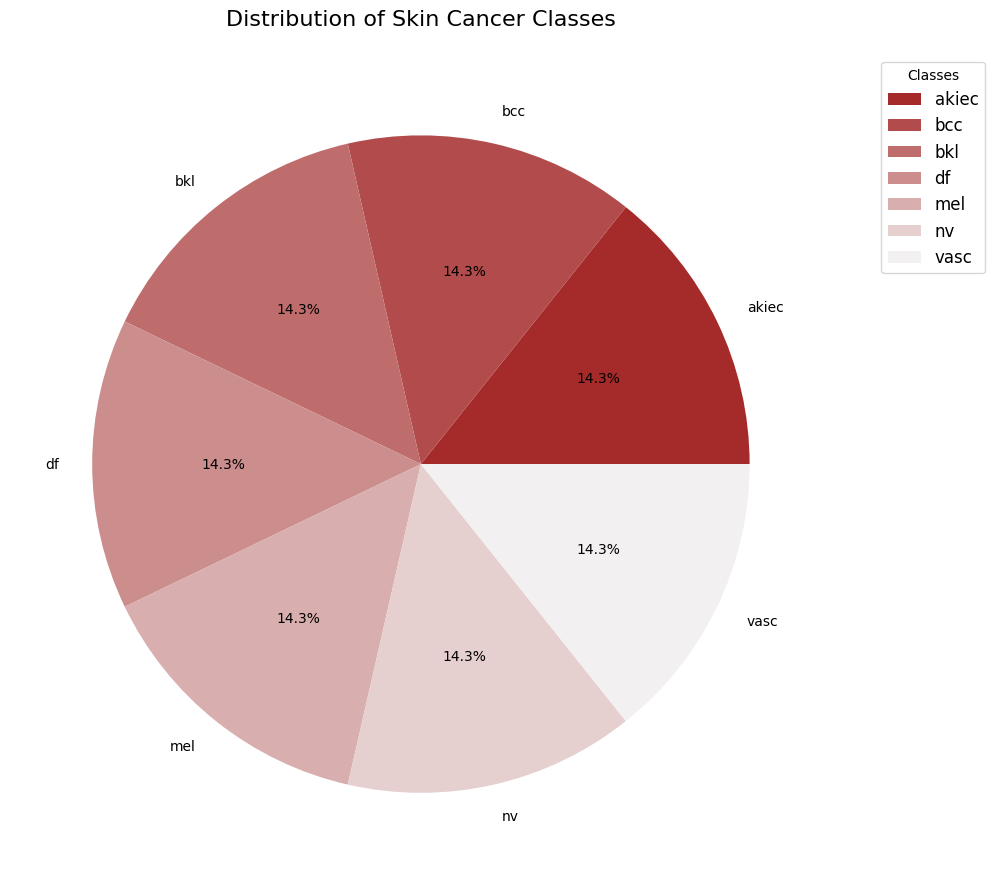

In [39]:
# Recalculate the class distribution to ensure it's up-to-date
count = metadata['dx'].value_counts().sort_index()

# Plot the distribution of skin cancer classes as a pie chart
fig, ax = plt.subplots(figsize=(10, 10))  # Set figure size for better readability

# Use the lighter brown color palette for the pie chart
count.plot(
    kind="pie",
    autopct='%1.1f%%', 
    colors=lighter_brown_colors, 
    legend=True, 
    ax=ax  
)

# Enhance the plot aesthetics
ax.set_ylabel('')  
ax.set_title('Distribution of Skin Cancer Classes', fontsize=16, pad=20) 

# Adjust the legend position and formatting for better visibility
ax.legend(
    title='Classes',
    bbox_to_anchor=(1.05, 1), 
    loc='upper left',  
    fontsize=12 
)

# Display the pie chart
plt.tight_layout()
plt.show()

**DATA EXPORT**

For `metadata['dx']`, the following mapping is used:

| Label | Full Name                          | Numeric Code |
|-------|------------------------------------|--------------|
| bkl   | Benign keratosis-like lesions     | 0            |
| nv    | Melanocytic nevi                  | 1            |
| df    | Dermatofibroma                    | 2            |
| mel   | Melanoma                          | 3            |
| vasc  | Vascular lesions                  | 4            |
| bcc   | Basal cell carcinoma              | 5            |
| akiec | Actinic keratoses / Bowen's disease | 6            |

In [40]:
# Define a mapping dictionary to convert categorical labels to numeric codes
enum_labels = {
    'bkl': 0,    # Benign keratosis-like lesions
    'nv': 1,     # Melanocytic nevi
    'df': 2,     # Dermatofibroma
    'mel': 3,    # Melanoma
    'vasc': 4,   # Vascular lesions
    'bcc': 5,    # Basal cell carcinoma
    'akiec': 6   # Actinic keratoses / Bowen's disease
}

# Replace the categorical labels in the 'dx' column with their corresponding numeric codes
# and store the result in a new column 'dx_cat' for better clarity and usability in modeling
metadata['dx_cat'] = metadata['dx'].replace(enum_labels)

# Log the unique values in the new 'dx_cat' column to verify the mapping
print("Unique values in 'dx_cat' column after mapping:", metadata['dx_cat'].unique())

Unique values in 'dx_cat' column after mapping: [1 0 2 3 4 5 6]


In [41]:
# Export the metadata DataFrame to a CSV file
# The file will be saved in the current working directory with the name 'data_enum.csv'
# The 'index=False' parameter ensures that the DataFrame index is not included in the CSV file
metadata.to_csv('data_enum.csv', index=False)

# Log a confirmation message to indicate successful export
print("Metadata has been successfully exported to 'data_enum.csv'.")

Metadata has been successfully exported to 'data_enum.csv'.


# Data Loader

**Objective**: Facilitate efficient data loading, transformation, and label extraction for model training.

In [42]:
# essential imports
import numpy as np
import pandas as pd
from tqdm import tqdm
from skimage import io, transform
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from PIL import Image

In [43]:
class HAM10000Dataset(Dataset):
    def __init__(self, dataframe, label_col='dx_cat', image_col='image_path', transform=None):
        self.dataframe = dataframe
        self.label_col = label_col
        self.image_col = image_col
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):
        img_path = self.dataframe.iloc[index][self.image_col]
        img = Image.open(img_path).convert("RGB")  # Ensure the image is in RGB format
        label = torch.tensor(self.dataframe.iloc[index][self.label_col], dtype=torch.long)

        if self.transform:
            img = self.transform(img)

        return img, label

# Model Training and Evaluation Functions

**Objective:** Provides essential functions for training, validating, testing, normalization and evaluating deep learning models.

In [51]:
# essential imports
import numpy as np
import pandas as pd
from tqdm import tqdm

from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
import seaborn as sns
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim
from torch.autograd import Variable
import torchvision
from torchvision import models,transforms

from PIL import Image
import cv2

In [52]:
def train_epoch(model, train_loader, criterion, optimizer, device):
    """
    Trains the model for one epoch using the provided data loader, loss function, and optimizer.

    Parameters:
    model (torch.nn.Module): The model to train.
    train_loader (torch.utils.data.DataLoader): DataLoader for the training dataset.
    criterion (torch.nn.Module): Loss function to compute the training loss.
    optimizer (torch.optim.Optimizer): Optimizer to update model parameters.
    device (torch.device): Device to perform computations on (e.g., 'cuda' or 'cpu').

    Returns:
    tuple: A tuple containing:
        - avg_train_loss (float): Average training loss for the epoch.
        - train_accuracy (float): Training accuracy as a percentage.
    """
    # Set the model to training mode
    model.train()

    # Initialize variables to track loss and accuracy
    train_loss = 0.0
    correct = 0
    total = 0

    # Iterate over the training data
    for data, labels in train_loader:
        # Move data and labels to the specified device
        data, labels = data.to(device), labels.to(device)
        
        # Zero the parameter gradients to avoid accumulation
        optimizer.zero_grad()

        # Forward pass: compute model predictions
        outputs = model(data)

        # Compute the loss
        loss = criterion(outputs, labels)

        # Backward pass: compute gradients
        loss.backward()

        # Update model parameters
        optimizer.step()

        # Accumulate the loss
        train_loss += loss.item()

        # Compute the number of correct predictions
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    # Calculate average loss and accuracy for the epoch
    avg_train_loss = train_loss / len(train_loader)
    train_accuracy = 100 * correct / total

    # Return the metrics
    return avg_train_loss, train_accuracy

In [53]:
def validate_epoch(model, val_loader, criterion, device):
    """
    Validates the model for one epoch using the provided validation data loader and loss function.

    Parameters:
    model (torch.nn.Module): The model to validate.
    val_loader (torch.utils.data.DataLoader): DataLoader for the validation dataset.
    criterion (torch.nn.Module): Loss function to compute the validation loss.
    device (torch.device): Device to perform computations on (e.g., 'cuda' or 'cpu').

    Returns:
    tuple: A tuple containing:
        - avg_valid_loss (float): Average validation loss for the epoch.
        - valid_accuracy (float): Validation accuracy as a percentage.
    """
    # Set the model to evaluation mode
    model.eval()

    # Initialize variables to track loss and accuracy
    valid_loss = 0.0
    correct_predictions = 0
    total_samples = 0

    # Disable gradient computation for validation to save memory and computation
    with torch.no_grad():
        for data, labels in val_loader:
            # Move data and labels to the specified device
            data, labels = data.to(device), labels.to(device)

            # Forward pass: compute model predictions
            outputs = model(data)

            # Compute the loss
            loss = criterion(outputs, labels)
            valid_loss += loss.item()

            # Compute the number of correct predictions
            _, predicted = torch.max(outputs, dim=1)
            total_samples += labels.size(0)
            correct_predictions += (predicted == labels).sum().item()

    # Calculate average loss and accuracy for the epoch
    avg_valid_loss = valid_loss / len(val_loader)
    valid_accuracy = 100 * correct_predictions / total_samples

    # Return the metrics
    return avg_valid_loss, valid_accuracy


In [54]:
def test_model(model, test_loader, device):
    """
    Evaluates the model on the test dataset and computes the test accuracy.

    Parameters:
    model (torch.nn.Module): The trained model to evaluate.
    test_loader (torch.utils.data.DataLoader): DataLoader for the test dataset.
    device (torch.device): Device to perform computations on (e.g., 'cuda' or 'cpu').

    Returns:
    float: Test accuracy as a percentage.
    """
    # Set the model to evaluation mode
    model.eval()

    # Initialize counters for correct predictions and total samples
    correct = 0
    total = 0

    # Disable gradient computation for testing to save memory and computation
    with torch.no_grad():
        for data, labels in test_loader:
            # Move data and labels to the specified device
            data, labels = data.to(device), labels.to(device)

            # Forward pass: compute model predictions
            outputs = model(data)

            # Get the predicted class with the highest score
            _, predicted = torch.max(outputs.data, dim=1)

            # Update the total number of samples and correct predictions
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    # Calculate test accuracy as a percentage
    test_accuracy = 100 * correct / total

    # Return the computed test accuracy
    return test_accuracy

In [55]:
def train_and_validate_model(model, train_loader, val_loader, test_loader, criterion, patience, optimizer, device, epochs, model_filename, verbose=False):
    """
    Trains and validates a PyTorch model with early stopping and saves the best model based on validation loss.

    Parameters:
    model (torch.nn.Module): The PyTorch model to train and validate.
    train_loader (DataLoader): DataLoader for the training dataset.
    val_loader (DataLoader): DataLoader for the validation dataset.
    test_loader (DataLoader): DataLoader for the test dataset.
    criterion (torch.nn.Module): Loss function to compute the loss.
    patience (int): Number of epochs to wait for improvement in validation loss before stopping.
    optimizer (torch.optim.Optimizer): Optimizer to update model parameters.
    device (torch.device): Device to perform computations on (e.g., 'cuda' or 'cpu').
    epochs (int): Maximum number of epochs to train the model.
    model_filename (str): Path to save the best model.
    verbose (bool): If True, prints detailed logs for each epoch.

    Returns:
    tuple: A tuple containing:
        - model (torch.nn.Module): The trained model with the best weights.
        - total_loss_train (list): List of training losses for each epoch.
        - total_loss_val (list): List of validation losses for each epoch.
        - total_acc_train (list): List of training accuracies for each epoch.
        - total_acc_val (list): List of validation accuracies for each epoch.
    """
    # Initialize variables to track the best validation loss and early stopping counter
    min_valid_loss = np.inf
    stopping_ct = 0

    # Lists to store metrics for each epoch
    total_loss_train = []
    total_loss_val = []
    total_acc_train = []
    total_acc_val = []

    # Training loop
    for epoch in tqdm(range(epochs), desc="Training Progress", unit="epoch"):
        if stopping_ct < patience:  # Check if early stopping criteria are met
            # Train the model for one epoch
            train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
            # Validate the model for one epoch
            valid_loss, valid_acc = validate_epoch(model, val_loader, criterion, device)

            # Append metrics to their respective lists
            total_loss_train.append(train_loss)
            total_loss_val.append(valid_loss)
            total_acc_train.append(train_acc)
            total_acc_val.append(valid_acc)

            # Print detailed logs if verbose is enabled
            if verbose:
                print(f"\nEpoch {epoch + 1}/{epochs}")
                print(f"Training Loss: {train_loss:.4f} | Training Accuracy: {train_acc:.2f}%")
                print(f"Validation Loss: {valid_loss:.4f} | Validation Accuracy: {valid_acc:.2f}%")
                print("=" * 70)

            # Save the model if validation loss improves
            if min_valid_loss > valid_loss:
                print(f"\nValidation Loss Improved ({min_valid_loss:.6f} --> {valid_loss:.6f})")
                print(f"Saving the model to {model_filename}")
                print("=" * 70)
                min_valid_loss = valid_loss
                torch.save(model.state_dict(), model_filename)
                stopping_ct = 0  # Reset early stopping counter
            else:
                stopping_ct += 1  # Increment early stopping counter

    # Load the best model weights
    print("\nLoading the best model weights...")
    best_model_state = torch.load(model_filename)
    model.load_state_dict(best_model_state)

    # Plot training and validation loss
    plt.figure(figsize=(10, 6))
    plt.plot(total_loss_train, label="Training Loss", color="blue", linestyle="--", marker="o")
    plt.plot(total_loss_val, label="Validation Loss", color="orange", linestyle="--", marker="o")
    plt.title("Training and Validation Loss", fontsize=16, pad=15)
    plt.xlabel("Epochs", fontsize=14, labelpad=10)
    plt.ylabel("Loss", fontsize=14, labelpad=10)
    plt.legend(fontsize=12)
    plt.grid(alpha=0.5)
    plt.tight_layout()
    plt.show()

    # Plot training and validation accuracy
    plt.figure(figsize=(10, 6))
    plt.plot(total_acc_train, label="Training Accuracy", color="green", linestyle="--", marker="o")
    plt.plot(total_acc_val, label="Validation Accuracy", color="red", linestyle="--", marker="o")
    plt.title("Training and Validation Accuracy", fontsize=16, pad=15)
    plt.xlabel("Epochs", fontsize=14, labelpad=10)
    plt.ylabel("Accuracy (%)", fontsize=14, labelpad=10)
    plt.legend(fontsize=12)
    plt.grid(alpha=0.5)
    plt.tight_layout()
    plt.show()

    return model, total_loss_train, total_loss_val, total_acc_train, total_acc_val

In [56]:
def set_parameter_requires_grad(model, feature_extracting):
    """
    Freezes the parameters of a model to prevent them from being updated during training.

    Parameters:
    model (torch.nn.Module): The model whose parameters need to be updated or frozen.
    feature_extracting (bool): If True, freezes all parameters to prevent gradient updates.
                                If False, allows all parameters to be updated during training.

    Returns:
    None
    """
    if feature_extracting:
        # Iterate through all parameters in the model
        for param in model.parameters():
            # Disable gradient computation for the parameter
            param.requires_grad = False


In [57]:
def initialise_model(model_name, num_classes, feature_extract, use_pretrained=True):
    """
    Initializes a deep learning model with specified configurations.

    Parameters:
    model_name (str): Name of the model to initialize. Options: 'resnet_pret', 'densenet_pret'.
    num_classes (int): Number of output classes for the model.
    feature_extract (bool): If True, freezes the pretrained weights to prevent updates.
    use_pretrained (bool): If True, loads pretrained weights; otherwise, initializes weights randomly.

    Returns:
    torch.nn.Module: The initialized model ready for training or inference.
    """
    # Initialize the model variable
    model = None

    # Check the model name and initialize accordingly
    if model_name == 'resnet_pret':
        # Load ResNet50 with pretrained weights if specified
        model_ft = models.resnet50(pretrained=use_pretrained)
        # Freeze layers if feature extraction is enabled
        set_parameter_requires_grad(model_ft, feature_extract)
        # Replace the fully connected layer to match the number of classes
        num_ftrs = model_ft.fc.in_features
        model_ft.fc = nn.Linear(num_ftrs, num_classes)
        print(f"ResNet50 initialized with {'pretrained' if use_pretrained else 'random'} weights.")
    elif model_name == 'densenet_pret':
        # Load DenseNet121 with pretrained weights if specified
        model_ft = models.densenet121(pretrained=use_pretrained)
        # Freeze layers if feature extraction is enabled
        set_parameter_requires_grad(model_ft, feature_extract)
        # Replace the classifier to match the number of classes
        num_ftrs = model_ft.classifier.in_features
        model_ft.classifier = nn.Linear(num_ftrs, num_classes)
        print(f"DenseNet121 initialized with {'pretrained' if use_pretrained else 'random'} weights.")
    else:
        # Handle invalid model names
        print("Invalid model name. Please choose between 'resnet_pret' and 'densenet_pret'.")
        return None

    # Return the initialized model
    return model_ft

In [58]:
def conf_report(model_fitted, loader, model_type):
    """
    Generate and display a confusion matrix and a classification report for the predictions made by a model.

    Parameters:
    - model_fitted: The trained model used to make predictions.
    - loader: DataLoader providing batches of data (data, labels).
    - model_type: A string indicating the type of the model (used for labeling outputs).

    Outputs:
    - Heatmaps for normalized and raw confusion matrices.
    - A classification report printed to the console.
    - Saves the confusion matrix figure as 'Confusion_Matrix_{model_type}.png'.
    """
    # Initialize lists to store predictions and true labels
    y_pred = []
    y_true = []

    # Move the model to CPU for evaluation
    model_cpu = model_fitted.to('cpu')
    model_cpu.eval()

    # Collect predictions and true labels from the data loader
    for data, target in loader:
        data, target = data.to('cpu'), target.to('cpu')
        output = model_cpu(data)
        y_pred.extend(output.argmax(dim=1).tolist())  # Predicted labels
        y_true.extend(target.tolist())  # True labels

    # Define class names
    classes = ['bkl', 'nv', 'df', 'mel', 'vasc', 'bcc', 'akiec']

    # Compute the confusion matrix
    cf_matrix = confusion_matrix(y_true, y_pred)

    # Normalize the confusion matrix
    normalized_cf_matrix = cf_matrix / np.sum(cf_matrix, axis=1, keepdims=True)

    # Create a DataFrame for the normalized confusion matrix
    df_normalized = pd.DataFrame(normalized_cf_matrix, index=classes, columns=classes)

    # Set up the figure for heatmaps
    fig, axes = plt.subplots(1, 2, figsize=(20, 8))
    fig.suptitle(f'Confusion Matrix for {model_type}', fontsize=18, fontweight='bold', y=1.02)

    # Plot the normalized confusion matrix
    sns.heatmap(
        df_normalized, annot=True, fmt=".2f", cmap='Blues', xticklabels=classes, yticklabels=classes,
        ax=axes[0], cbar=False, linewidths=0.5, linecolor='black'
    )
    axes[0].set_title('Normalized Confusion Matrix', fontsize=14, pad=15)
    axes[0].set_xlabel('Predicted Labels', fontsize=12, labelpad=10)
    axes[0].set_ylabel('True Labels', fontsize=12, labelpad=10)

    # Plot the raw confusion matrix
    sns.heatmap(
        cf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes,
        ax=axes[1], cbar=False, linewidths=0.5, linecolor='black'
    )
    axes[1].set_title('Raw Confusion Matrix', fontsize=14, pad=15)
    axes[1].set_xlabel('Predicted Labels', fontsize=12, labelpad=10)
    axes[1].set_ylabel('True Labels', fontsize=12, labelpad=10)

    # Adjust layout and save the figure
    plt.tight_layout()
    plt.savefig(f'Confusion_Matrix_{model_type}.png', bbox_inches='tight')
    plt.show()

    # Generate and print the classification report
    report = classification_report(y_true, y_pred, target_names=classes, digits=3)
    print('-------------------------------------------------------')
    print(f"Classification Report for {model_type}:\n")
    print(report)
    print('-------------------------------------------------------')

In [59]:
def compute_img_mean_std(image_paths, img_h, img_w):
    """
    Compute the mean and standard deviation of RGB channels across the entire dataset.

    This function processes images one by one to avoid memory overflow, 
    resizing them to the specified dimensions and calculating the mean and 
    standard deviation for each channel.

    Args:
        image_paths (list): List of image file paths.
        img_h (int): Height in pixels to resize the images.
        img_w (int): Width in pixels to resize the images.

    Returns:
        tuple: A tuple containing:
            - means (list): Mean values for the RGB channels.
            - stdevs (list): Standard deviation values for the RGB channels.
    """
    # Initialize variables to store cumulative sums and squared sums for each channel
    n_images = len(image_paths)
    channel_sum = np.zeros(3)  # For R, G, B channels
    channel_sum_squared = np.zeros(3)

    print(f"Processing {n_images} images to compute mean and standard deviation...")
    print("=" * 70)

    # Iterate through each image path
    for path in tqdm(image_paths, desc="Processing Images", unit="image"):
        # Read the image (default is BGR format)
        img = cv2.imread(path)
        
        # Resize the image to the specified dimensions
        img = cv2.resize(img, (img_w, img_h))
        
        # Convert the image from BGR to RGB format
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        # Normalize pixel values to the range [0, 1]
        img = img.astype(np.float32) / 255.0

        # Accumulate the sum and squared sum for each channel
        channel_sum += np.sum(img, axis=(0, 1))
        channel_sum_squared += np.sum(np.square(img), axis=(0, 1))

    # Calculate the mean for each channel
    means = channel_sum / (img_h * img_w * n_images)
    
    # Calculate the standard deviation for each channel
    stdevs = np.sqrt(channel_sum_squared / (img_h * img_w * n_images) - np.square(means))

    # Display the results with improved formatting
    print("\nComputation Complete!")
    print("=" * 70)
    print(f"Mean Values (RGB): {means}")
    print(f"Standard Deviations (RGB): {stdevs}")
    print("=" * 70)

    # Return the computed means and standard deviations
    return means, stdevs

# Model Builiding and Training

In [53]:
# essential imports
import os
import glob
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import random
from tqdm import tqdm

from skimage import io, transform
from sklearn.model_selection import train_test_split
from sklearn.metrics import  accuracy_score

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchsummary import summary
import torch.optim as optim
from torch.autograd import Variable
import torchvision
from torchvision import models,transforms

import time

import random
from PIL import Image
import cv2
import gc
import optuna
import logging

In [54]:
# read the data from the CSV file
data = pd.read_csv('data_enum.csv')
data = data.sample(frac=1)
data.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization,dup_les,image_path,dx_cat
29951,HAM_0007308,ISIC_0026848,akiec,histo,55,male,face,False,/home/asad/Thesis Practical part/dataset/HAM10...,6
5364,HAM_0006466,ISIC_0024495,bkl,histo,45,female,lower extremity,False,/home/asad/Thesis Practical part/dataset/HAM10...,0
4976,HAM_0003739,ISIC_0026675,bkl,histo,35,female,face,False,/home/asad/Thesis Practical part/dataset/HAM10...,0
14771,HAM_0006978,ISIC_0029316,mel,histo,45,female,neck,False,/home/asad/Thesis Practical part/dataset/HAM10...,3
28021,HAM_0007131,ISIC_0031692,akiec,histo,60,male,back,False,/home/asad/Thesis Practical part/dataset/HAM10...,6


**PREPROCESSING**

In [55]:
# normalize the data
img_h, img_w = 224, 224
norm_means = [0.77148203, 0.55764165, 0.58345652]
norm_std = [0.12655577, 0.14245141, 0.15189891]

**Data Augmentation and normalization**

**Resize the data as 244X244 because most pretrainned models are that size**

In [56]:
# define the transformation of the train images.
transform = transforms.Compose([transforms.Resize((img_h,img_w)),transforms.RandomHorizontalFlip(),
                                      transforms.RandomVerticalFlip(),transforms.RandomRotation(20),
                                      transforms.ColorJitter(brightness=0.1, contrast=0.1, hue=0.1),
                                        transforms.ToTensor(), transforms.Normalize(norm_means, norm_std)])
# define the transformation of the val and test images.
val_test_transform = transforms.Compose([transforms.Resize((img_h,img_w)), transforms.ToTensor(),
                                        transforms.Normalize(norm_means, norm_std)])

In [57]:
# split the data into train, val and test sets
data.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization,dup_les,image_path,dx_cat
29951,HAM_0007308,ISIC_0026848,akiec,histo,55,male,face,False,/home/asad/Thesis Practical part/dataset/HAM10...,6
5364,HAM_0006466,ISIC_0024495,bkl,histo,45,female,lower extremity,False,/home/asad/Thesis Practical part/dataset/HAM10...,0
4976,HAM_0003739,ISIC_0026675,bkl,histo,35,female,face,False,/home/asad/Thesis Practical part/dataset/HAM10...,0
14771,HAM_0006978,ISIC_0029316,mel,histo,45,female,neck,False,/home/asad/Thesis Practical part/dataset/HAM10...,3
28021,HAM_0007131,ISIC_0031692,akiec,histo,60,male,back,False,/home/asad/Thesis Practical part/dataset/HAM10...,6


**DATA LOADING**

In [58]:
# Split the data into training+validation and test sets (80% train+val, 20% test)
train_val_data, test_data = train_test_split(data, test_size=0.2, random_state=42)

# Further split the training+validation set into training and validation sets (50% train, 50% val)
train_data, val_data = train_test_split(train_val_data, test_size=0.5, random_state=42)

# Create the training dataset with transformations applied
train_dataset = HAM10000Dataset(train_data, transform=transform)

# Create the validation dataset with transformations applied
val_dataset = HAM10000Dataset(val_data, transform=transform)

# Create the test dataset with transformations applied
test_dataset = HAM10000Dataset(test_data, transform=transform)

In [80]:
# Define batch size and number of workers for data loading
batch_size = 64
num_workers = 4

# Create DataLoaders for training, validation, and testing datasets
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers)
val_loader = DataLoader(val_dataset, batch_size=batch_size, num_workers=num_workers)
test_loader = DataLoader(test_dataset, batch_size=batch_size, num_workers=num_workers)

# Print the number of samples in each dataset with improved formatting
print("=" * 50)
print(f"{'Dataset':<15}{'Number of Samples':>20}")
print("-" * 50)
print(f"{'Training':<15}{len(train_dataset):>20}")
print(f"{'Validation':<15}{len(val_dataset):>20}")
print(f"{'Testing':<15}{len(test_dataset):>20}")
print("=" * 50)

Dataset           Number of Samples
--------------------------------------------------
Training                      12362
Validation                    12362
Testing                        6181


**BATCH CHECK**

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-6.095985..2.9126241].


Displaying a batch of training images:


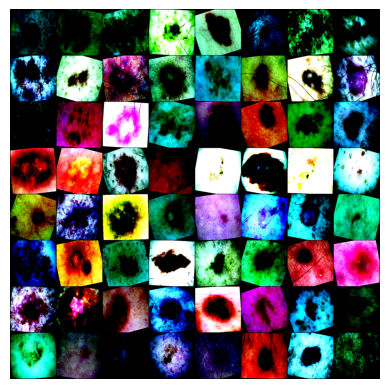

Labels for the displayed images:
[0, 5, 3, 3, 4, 3, 5, 3, 3, 5, 2, 2, 5, 2, 6, 5, 3, 1, 2, 6, 0, 1, 0, 3, 2, 2, 5, 0, 5, 3, 5, 5, 4, 6, 2, 2, 4, 5, 0, 5, 3, 2, 2, 3, 3, 5, 1, 2, 6, 3, 0, 0, 1, 1, 3, 3, 5, 4, 6, 0, 4, 1, 0, 6]


In [60]:
def imshow(img):
    """
    Display a batch of images in a grid format.

    Parameters:
    img (torch.Tensor): A tensor containing a batch of images.

    Returns:
    None
    """
    # Convert the tensor to a NumPy array and transpose dimensions for display
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.axis('off')  # Hide axes for better visualization
    plt.show()

# Fetch a batch of training data
data_iter = iter(train_loader)
images, labels = next(data_iter)

# Display the images in a grid format
print("Displaying a batch of training images:")
imshow(torchvision.utils.make_grid(images))

# Display the corresponding labels
print("Labels for the displayed images:")
print(labels.tolist())

In [61]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f'Using device: {device}')

Using device: cuda


**HYPERPARAMETERS TUNNNING**

In [81]:
# balanced subsample split
selected_data = data.groupby('dx').apply(lambda x: x.sample(n=500)).reset_index(drop=True)
selected_data.head()

/tmp/ipykernel_1289882/223024152.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  selected_data = data.groupby('dx').apply(lambda x: x.sample(n=500)).reset_index(drop=True)


,lesion_id,image_id,dx,dx_type,age,sex,localization,dup_les,image_path,dx_cat
0,HAM_0002061,ISIC_0030408,akiec,histo,80,male,scalp,False,/home/asad/Thesis Practical part/dataset/HAM10...,6
1,HAM_0000859,ISIC_0029715,akiec,histo,70,male,lower extremity,False,/home/asad/Thesis Practical part/dataset/HAM10...,6
2,HAM_0001258,ISIC_0025331,akiec,histo,80,male,face,False,/home/asad/Thesis Practical part/dataset/HAM10...,6
3,HAM_0001173,ISIC_0030827,akiec,histo,40,female,face,False,/home/asad/Thesis Practical part/dataset/HAM10...,6
4,HAM_0001526,ISIC_0027795,akiec,histo,70,male,ear,False,/home/asad/Thesis Practical part/dataset/HAM10...,6


In [63]:
class CNNet_trial(nn.Module):
    def __init__(self, num_filters, num_classes, num_of_layers):
        """
        Initializes the CNN model with multiple convolutional layers followed by fully connected layers.

        Parameters:
        - num_filters (list): List of integers specifying the number of filters for each convolutional layer.
        - num_classes (int): Number of output classes for classification.
        - num_of_layers (int): Number of convolutional layers in the network.
        """
        super(CNNet_trial, self).__init__()
        
        # Initialize a list to hold the convolutional layers
        self.layers = nn.ModuleList()
        in_channels = 3  # Input channels for the first layer (RGB images have 3 channels)
        
        # Create convolutional layers dynamically based on the num_filters list
        for out_channels in num_filters:
            self.layers.append(nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),  # Convolutional layer
                nn.BatchNorm2d(out_channels),  # Batch normalization for faster convergence
                nn.ReLU(),  # Activation function
                nn.MaxPool2d(kernel_size=2, stride=2)  # Max pooling to reduce spatial dimensions
            ))
            in_channels = out_channels  # Update in_channels for the next layer
        
        # Calculate the number of features after the convolutional layers
        self.flat_features = int(num_filters[-1] * (224 / 2**num_of_layers) * (224 / 2**num_of_layers))
        
        # Define fully connected layers
        self.fc1 = nn.Linear(self.flat_features, 512)  # First fully connected layer
        self.fc2 = nn.Linear(512, 128)  # Second fully connected layer
        self.fc3 = nn.Linear(128, num_classes)  # Output layer for classification

    def forward(self, x):
        """
        Defines the forward pass of the model.

        Parameters:
        - x (torch.Tensor): Input tensor of shape (batch_size, channels, height, width).

        Returns:
        - torch.Tensor: Output tensor with predictions for each class.
        """
        # Pass the input through each convolutional layer
        for layer in self.layers:
            x = layer(x)
        
        # Flatten the output of the convolutional layers
        x = x.view(x.size(0), -1)
        
        # Pass through the fully connected layers with ReLU activations
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)  # Output layer (no activation, as it will be handled by the loss function)
        
        return x

In [64]:
# Split the selected data into training+validation and test sets (80% train+val, 20% test)
train_val_trial, test_trial = train_test_split(selected_data, test_size=0.2, random_state=42)

# Further split the training+validation set into training and validation sets (50% train, 50% val)
train_trial, val_trial = train_test_split(train_val_trial, test_size=0.5, random_state=42)

# Create datasets for training, validation, and testing with appropriate transformations
train_trial = HAM10000Dataset(train_trial, transform=transform)
val_trial = HAM10000Dataset(val_trial, transform=transform)
test_trial = HAM10000Dataset(test_trial, transform=transform)

# Define batch size and number of workers for data loading
batch_size = 64
num_workers = 5

# Create DataLoaders for training, validation, and testing datasets
train_loader_trial = DataLoader(train_trial, batch_size=batch_size, shuffle=True, num_workers=num_workers)
val_loader_trial = DataLoader(val_trial, batch_size=batch_size, num_workers=num_workers)
test_loader_trial = DataLoader(test_trial, batch_size=batch_size, num_workers=num_workers)

# Print the number of samples in each dataset with improved formatting
print("=" * 60)
print(f"{'Dataset':<20}{'Number of Samples':>20}")
print("-" * 60)
print(f"{'Training':<20}{len(train_trial):>20}")
print(f"{'Validation':<20}{len(val_trial):>20}")
print(f"{'Testing':<20}{len(test_trial):>20}")
print("=" * 60)

Dataset                Number of Samples
------------------------------------------------------------
Training                            1400
Validation                          1400
Testing                              700


**SET THE OPTUNA PARAMETERS**

In [82]:
# Set Optuna logging verbosity to WARNING to reduce unnecessary logs
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    """
    Objective function for Optuna hyperparameter optimization.

    Parameters:
    trial (optuna.trial.Trial): A single trial object for hyperparameter optimization.

    Returns:
    float: The maximum validation accuracy achieved during the trial.
    """
    # Suggest the number of convolutional layers (3 or 4)
    num_of_layers = trial.suggest_int('num_of_layers', 3, 4)

    # Suggest filter configurations based on the number of layers
    if num_of_layers == 4:
        num_filters = trial.suggest_categorical(
            'num_filters_4_layers',
            [
                [16, 32, 64, 128], [32, 64, 128, 256], [64, 128, 256, 512],
                [16, 32, 128, 512], [32, 32, 64, 256], [32, 128, 256, 256],
                [32, 128, 128, 256], [128, 256, 512, 512]
            ]
        )
    else:
        num_filters = trial.suggest_categorical(
            'num_filters_3_layers',
            [
                [16, 64, 128], [32, 128, 256], [64, 128, 256], [128, 256, 512],
                [16, 32, 64], [16, 32, 128], [32, 128, 128], [64, 256, 256],
                [32, 256, 512], [16, 128, 512]
            ]
        )

    # Suggest learning rate and optimizer
    learning_rate = trial.suggest_categorical('learning_rate', [1e-4, 1e-3])
    optimizer_name = trial.suggest_categorical('optimizer', ['Adam', 'RMSprop', 'SGD', 'AdamW'])

    # Define training parameters
    epochs = 30
    patience = 5

    # Initialize the model with the suggested parameters
    model = CNNet_trial(num_filters=num_filters, num_classes=7, num_of_layers=num_of_layers)
    model = model.to(device)

    # Define the loss function
    criterion = nn.CrossEntropyLoss().to(device)

    # Initialize the optimizer based on the suggested optimizer name
    optimizer = {
        'Adam': optim.Adam(model.parameters(), lr=learning_rate),
        'RMSprop': optim.RMSprop(model.parameters(), lr=learning_rate),
        'SGD': optim.SGD(model.parameters(), lr=learning_rate),
        'AdamW': optim.AdamW(model.parameters(), lr=learning_rate)
    }[optimizer_name]

    # Define the filename for saving the best model
    model_filename = f'CNN_model_trial_{trial.number}.pth'

    try:
        # Train and validate the model
        _, _, _, _, total_acc_val = train_and_validate_model(
            model=model,
            train_loader=train_loader_trial,
            val_loader=val_loader_trial,
            test_loader=test_loader_trial,
            criterion=criterion,
            patience=patience,
            optimizer=optimizer,
            device=device,
            epochs=epochs,
            model_filename=model_filename,
            verbose=False
        )

        # Return the maximum validation accuracy achieved
        return max(total_acc_val)

    finally:
        # Clean up to free memory
        del model, optimizer
        torch.cuda.empty_cache()
        gc.collect()


Starting Optuna Hyperparameter Optimization...


  0%|          | 0/10 [00:00<?, ?it/s]


Validation Loss Improved (inf --> 1.654209)
Saving the model to CNN_model_trial_0.pth

Validation Loss Improved (1.654209 --> 1.449157)
Saving the model to CNN_model_trial_0.pth



Validation Loss Improved (1.449157 --> 1.217727)
Saving the model to CNN_model_trial_0.pth



Validation Loss Improved (1.217727 --> 1.187120)
Saving the model to CNN_model_trial_0.pth


...


Validation Loss Improved (0.829279 --> 0.827763)
Saving the model to CNN_model_trial_0.pth



Validation Loss Improved (0.827763 --> 0.821040)
Saving the model to CNN_model_trial_0.pth



Validation Loss Improved (0.821040 --> 0.751390)
Saving the model to CNN_model_trial_0.pth


Training Progress: 100%|██████████| 30/30 [01:49<00:00,  3.64s/epoch]


Loading the best model weights...


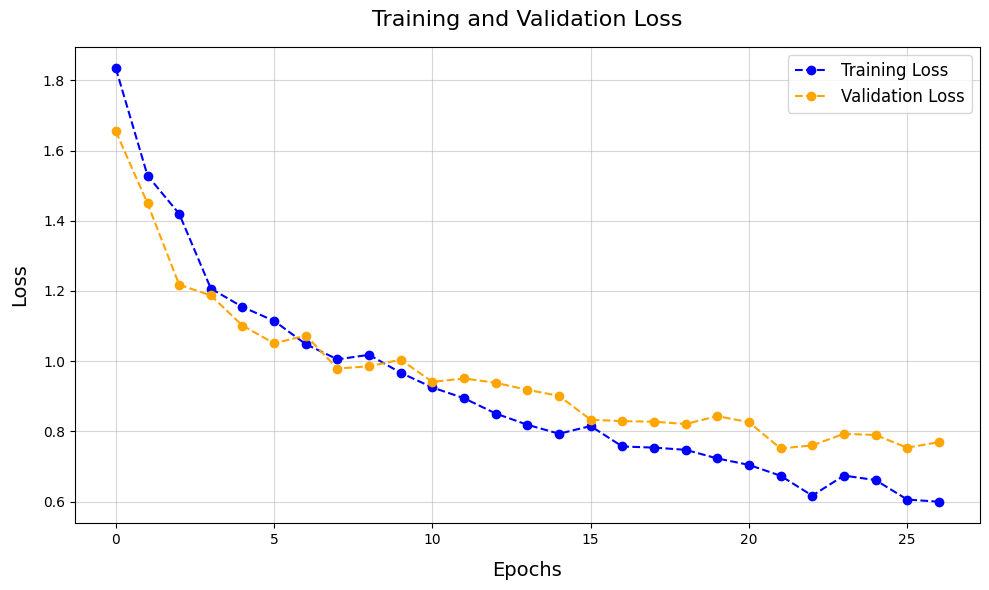

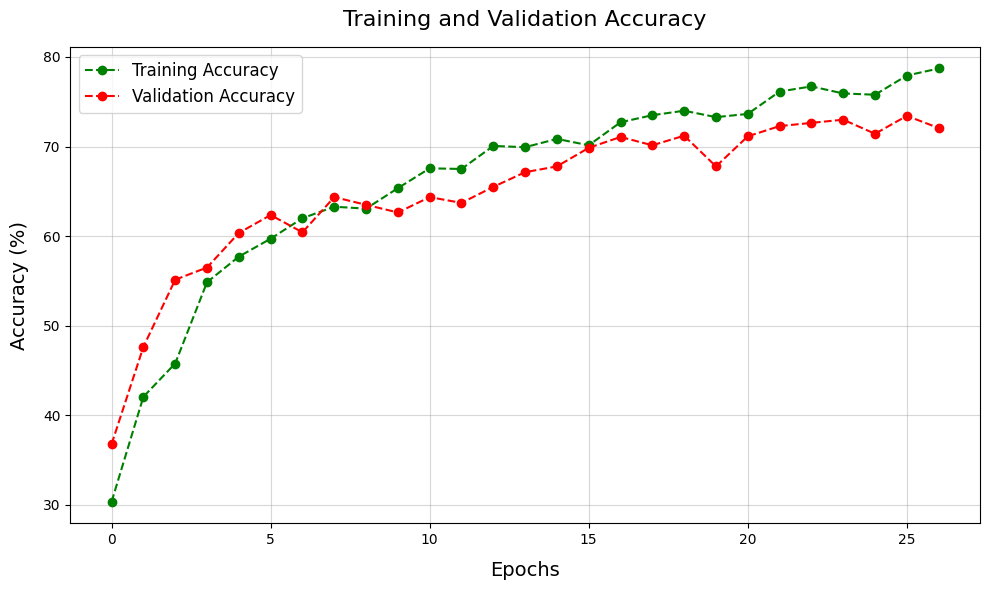


Validation Loss Improved (inf --> 1.752408)
Saving the model to CNN_model_trial_1.pth



Validation Loss Improved (1.752408 --> 1.533224)
Saving the model to CNN_model_trial_1.pth



Validation Loss Improved (1.533224 --> 1.526797)
Saving the model to CNN_model_trial_1.pth



Validation Loss Improved (1.526797 --> 1.404703)
Saving the model to CNN_model_trial_1.pth



Validation Loss Improved (1.404703 --> 1.359564)
Saving the model to CNN_model_trial_1.pth


...


Validation Loss Improved (0.935089 --> 0.905020)
Saving the model to CNN_model_trial_1.pth



Validation Loss Improved (0.905020 --> 0.898492)
Saving the model to CNN_model_trial_1.pth



Validation Loss Improved (0.898492 --> 0.866509)
Saving the model to CNN_model_trial_1.pth


Training Progress: 100%|██████████| 30/30 [01:59<00:00,  3.98s/epoch]


Loading the best model weights...


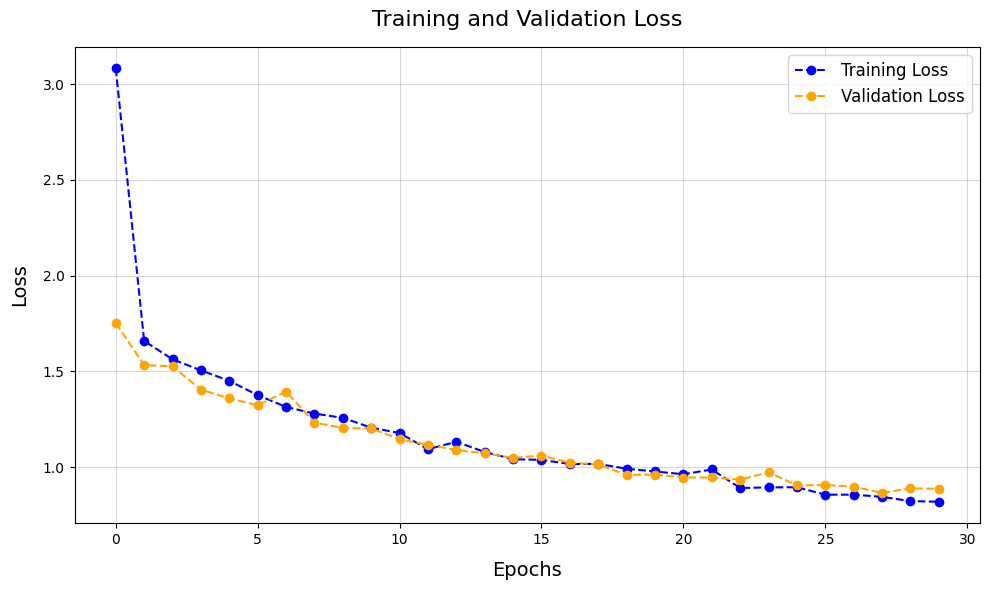

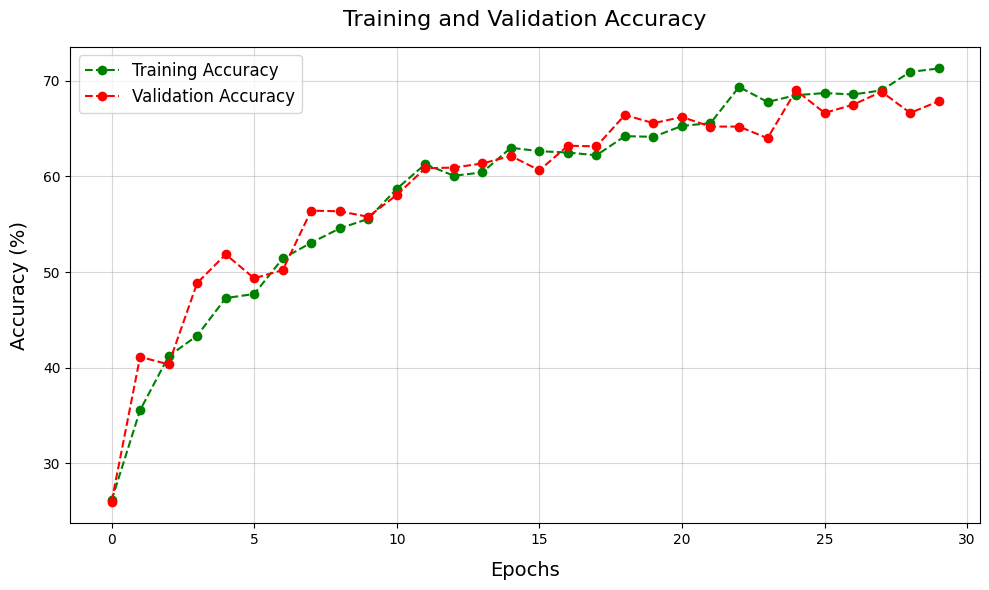


Validation Loss Improved (inf --> 1.897433)
Saving the model to CNN_model_trial_2.pth



Validation Loss Improved (1.897433 --> 1.510286)
Saving the model to CNN_model_trial_2.pth



Validation Loss Improved (1.510286 --> 1.459146)
Saving the model to CNN_model_trial_2.pth



Validation Loss Improved (1.459146 --> 1.376450)
Saving the model to CNN_model_trial_2.pth



Validation Loss Improved (1.376450 --> 1.245200)
Saving the model to CNN_model_trial_2.pth


...


Validation Loss Improved (1.208656 --> 1.046975)
Saving the model to CNN_model_trial_2.pth



Validation Loss Improved (1.046975 --> 0.996373)
Saving the model to CNN_model_trial_2.pth



Validation Loss Improved (0.996373 --> 0.930912)
Saving the model to CNN_model_trial_2.pth


Training Progress: 100%|██████████| 30/30 [01:31<00:00,  3.06s/epoch]



Loading the best model weights...


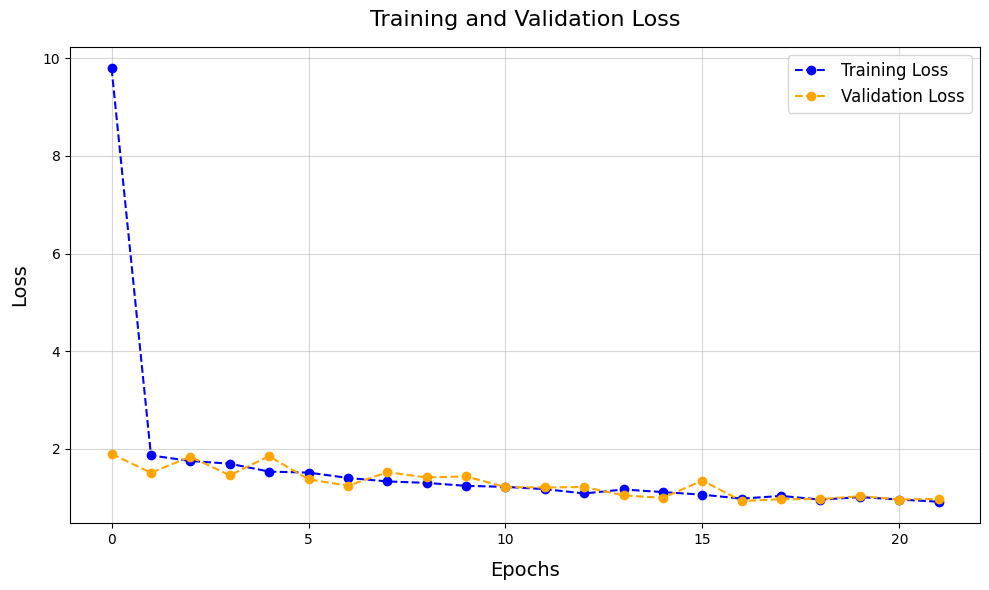

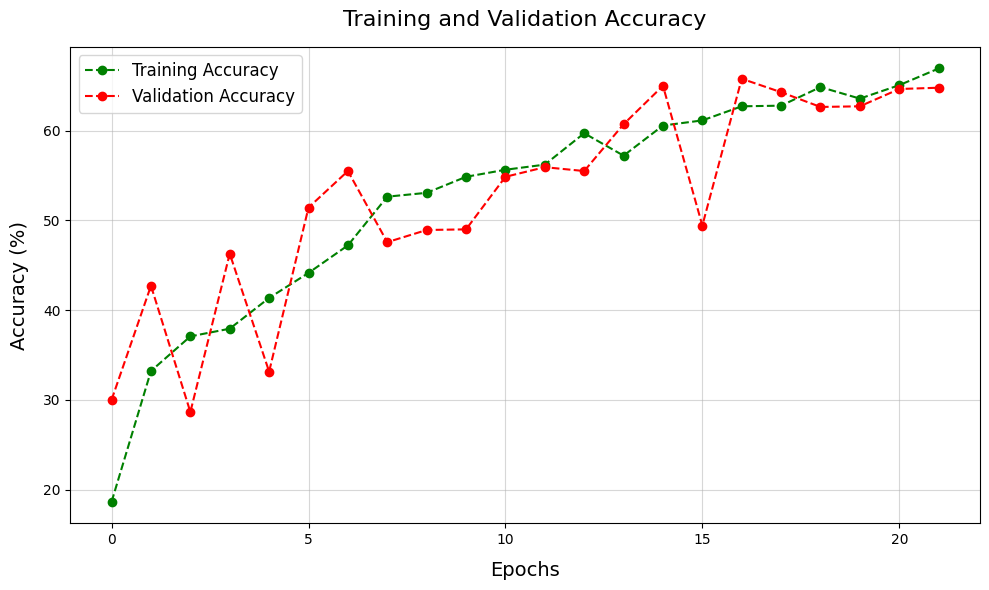


Validation Loss Improved (inf --> 1.657458)
Saving the model to CNN_model_trial_3.pth

Validation Loss Improved (1.657458 --> 1.388481)
Saving the model to CNN_model_trial_3.pth



Validation Loss Improved (1.388481 --> 1.316655)
Saving the model to CNN_model_trial_3.pth



Validation Loss Improved (1.316655 --> 1.235093)
Saving the model to CNN_model_trial_3.pth



Validation Loss Improved (1.235093 --> 1.178517)
Saving the model to CNN_model_trial_3.pth



Validation Loss Improved (1.178517 --> 1.090062)
Saving the model to CNN_model_trial_3.pth


...


Validation Loss Improved (0.870113 --> 0.860573)
Saving the model to CNN_model_trial_3.pth



Validation Loss Improved (0.860573 --> 0.799215)
Saving the model to CNN_model_trial_3.pth



Validation Loss Improved (0.799215 --> 0.768415)
Saving the model to CNN_model_trial_3.pth


Training Progress: 100%|██████████| 30/30 [02:01<00:00,  4.03s/epoch]


Loading the best model weights...


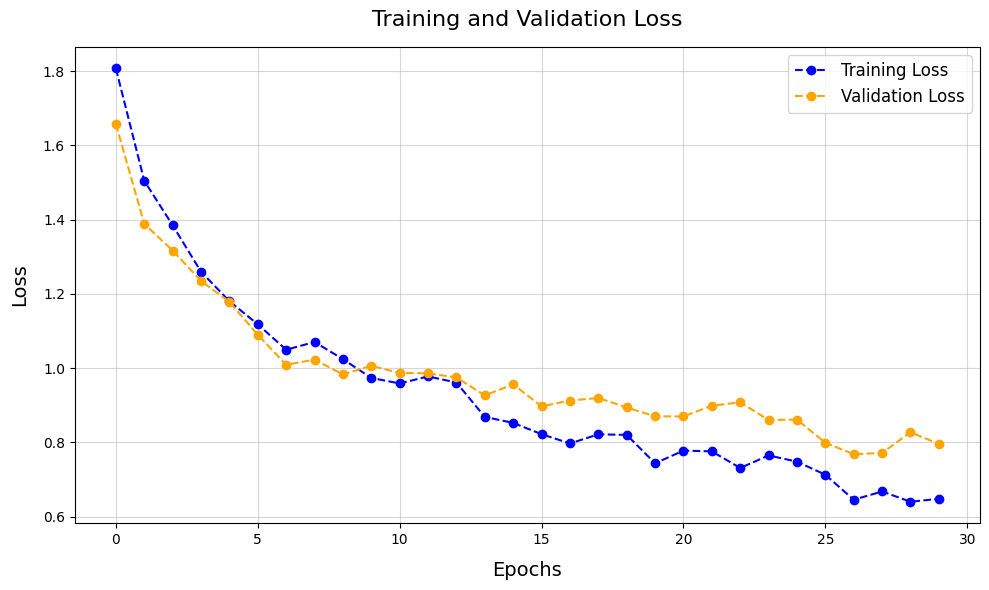

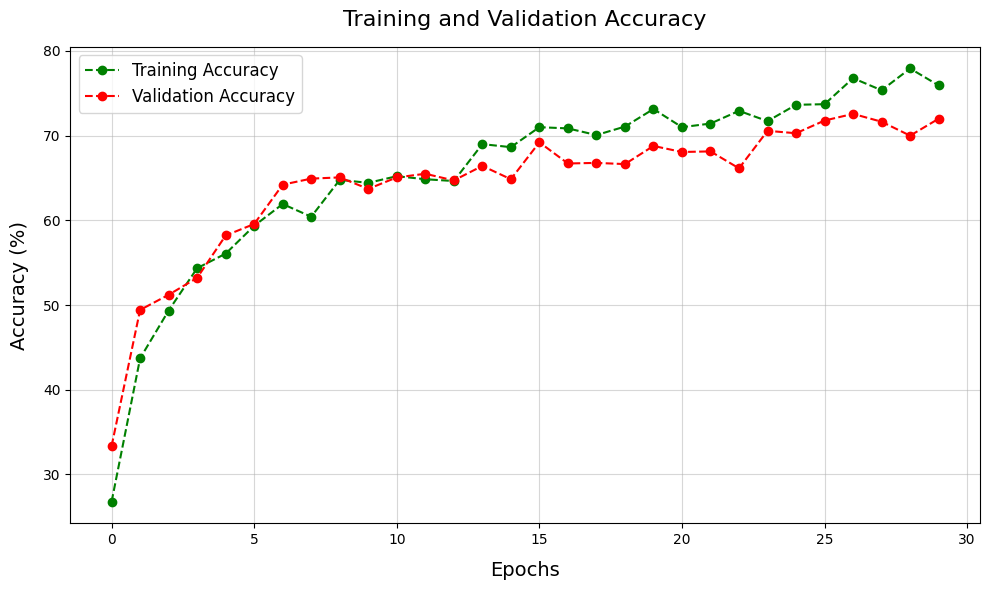


Validation Loss Improved (inf --> 1.819416)
Saving the model to CNN_model_trial_4.pth



Validation Loss Improved (1.819416 --> 1.549667)
Saving the model to CNN_model_trial_4.pth



Validation Loss Improved (1.549667 --> 1.478201)
Saving the model to CNN_model_trial_4.pth



Validation Loss Improved (1.478201 --> 1.296413)
Saving the model to CNN_model_trial_4.pth



Validation Loss Improved (1.296413 --> 1.224641)
Saving the model to CNN_model_trial_4.pth


...


Validation Loss Improved (0.871135 --> 0.850805)
Saving the model to CNN_model_trial_4.pth



Validation Loss Improved (0.850805 --> 0.778599)
Saving the model to CNN_model_trial_4.pth



Validation Loss Improved (0.778599 --> 0.764049)
Saving the model to CNN_model_trial_4.pth


Training Progress: 100%|██████████| 30/30 [01:59<00:00,  4.00s/epoch]


Loading the best model weights...


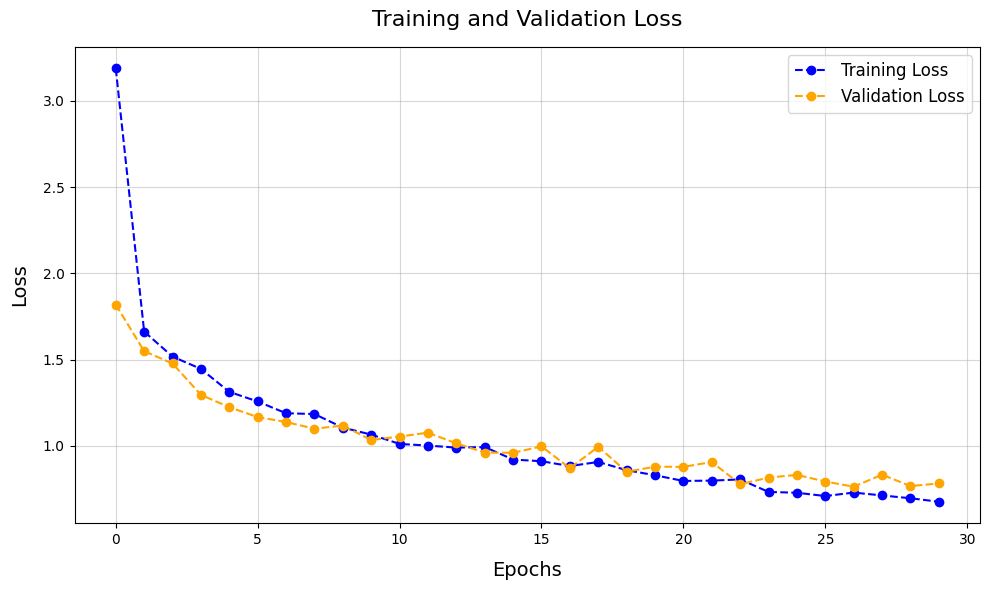

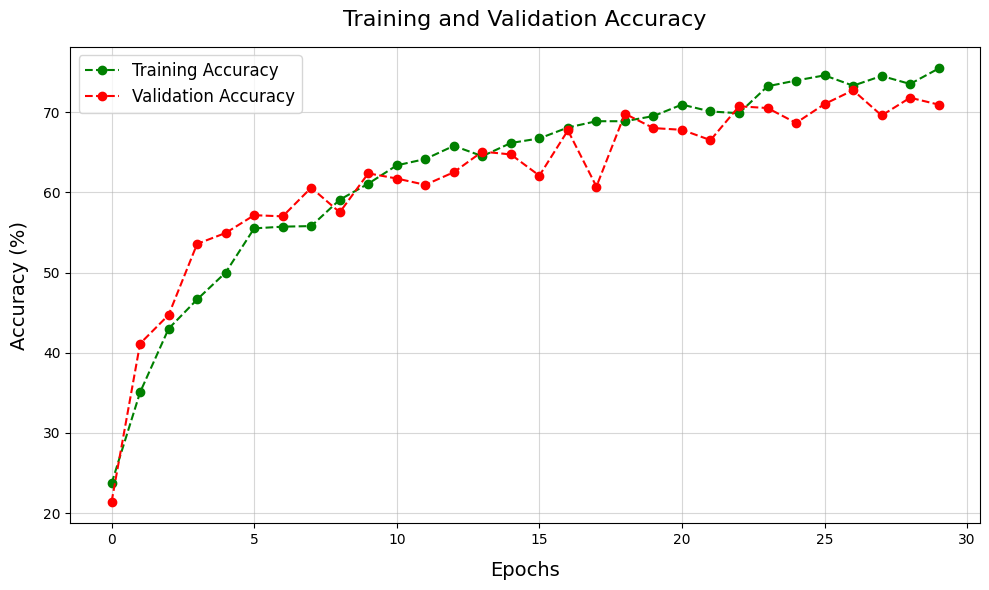


Validation Loss Improved (inf --> 1.607757)
Saving the model to CNN_model_trial_5.pth

Validation Loss Improved (1.607757 --> 1.480921)
Saving the model to CNN_model_trial_5.pth



Validation Loss Improved (1.480921 --> 1.259672)
Saving the model to CNN_model_trial_5.pth



Validation Loss Improved (1.259672 --> 1.150615)
Saving the model to CNN_model_trial_5.pth



Validation Loss Improved (1.150615 --> 1.115115)
Saving the model to CNN_model_trial_5.pth



Validation Loss Improved (1.115115 --> 1.014147)
Saving the model to CNN_model_trial_5.pth


...


Validation Loss Improved (0.742940 --> 0.708881)
Saving the model to CNN_model_trial_5.pth



Validation Loss Improved (0.708881 --> 0.690120)
Saving the model to CNN_model_trial_5.pth



Validation Loss Improved (0.690120 --> 0.658484)
Saving the model to CNN_model_trial_5.pth


Training Progress: 100%|██████████| 30/30 [02:02<00:00,  4.09s/epoch]


Loading the best model weights...


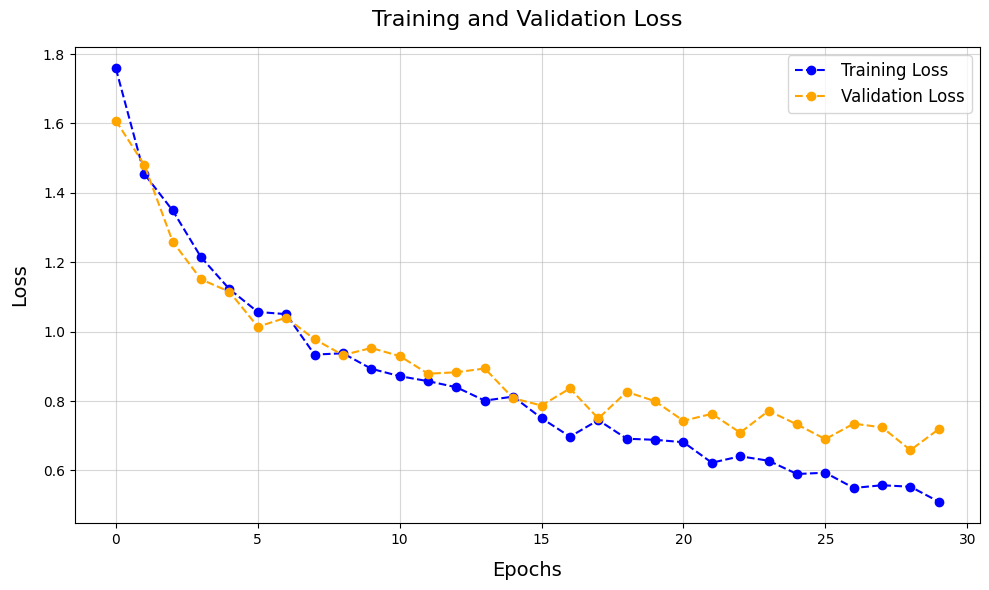

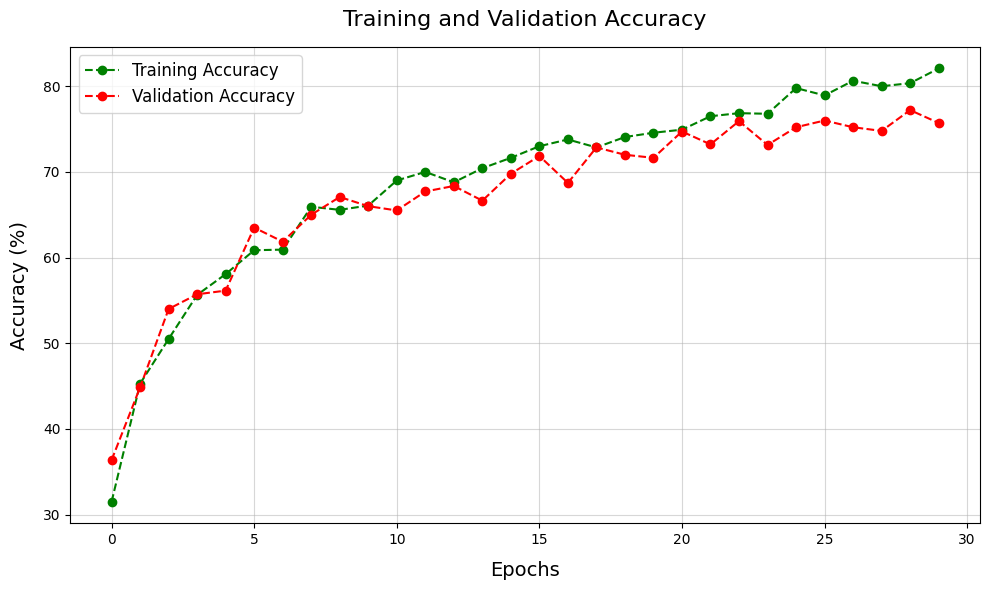


Validation Loss Improved (inf --> 1.654582)
Saving the model to CNN_model_trial_6.pth



Validation Loss Improved (1.654582 --> 1.362559)
Saving the model to CNN_model_trial_6.pth



Validation Loss Improved (1.362559 --> 1.340730)
Saving the model to CNN_model_trial_6.pth



Validation Loss Improved (1.340730 --> 1.186243)
Saving the model to CNN_model_trial_6.pth



Validation Loss Improved (1.186243 --> 1.152517)
Saving the model to CNN_model_trial_6.pth


...


Validation Loss Improved (0.819168 --> 0.806642)
Saving the model to CNN_model_trial_6.pth



Validation Loss Improved (0.806642 --> 0.740643)
Saving the model to CNN_model_trial_6.pth



Validation Loss Improved (0.740643 --> 0.727933)
Saving the model to CNN_model_trial_6.pth


Training Progress: 100%|██████████| 30/30 [01:58<00:00,  3.96s/epoch]


Loading the best model weights...


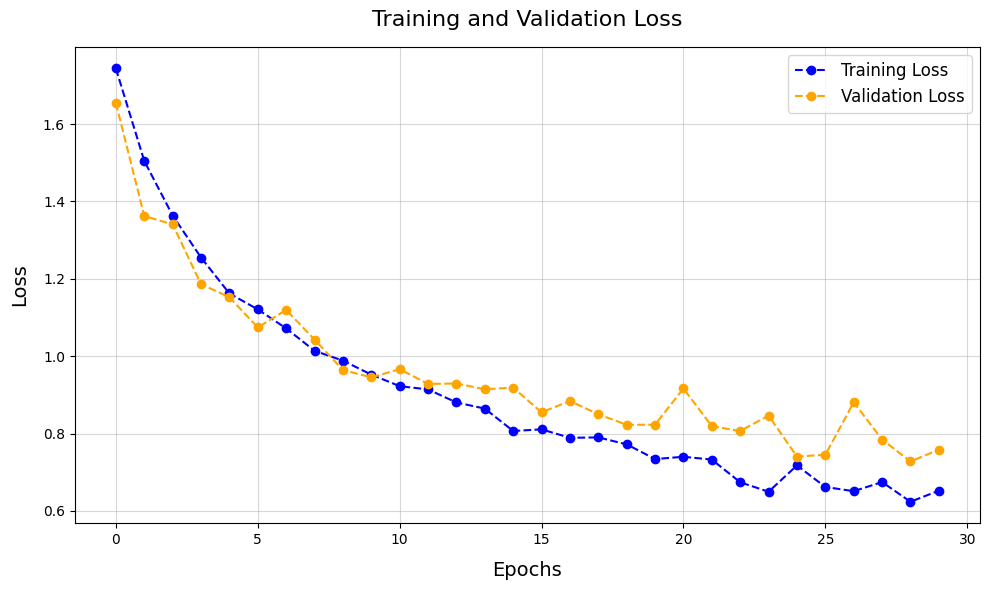

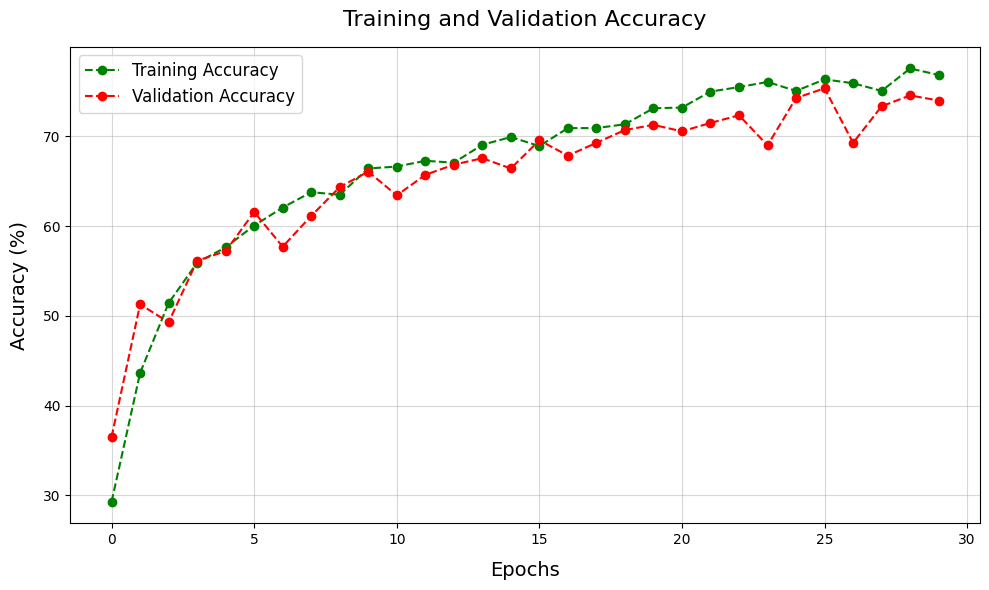


Validation Loss Improved (inf --> 2.258530)
Saving the model to CNN_model_trial_7.pth

Validation Loss Improved (2.258530 --> 1.606585)
Saving the model to CNN_model_trial_7.pth



Validation Loss Improved (1.606585 --> 1.452040)
Saving the model to CNN_model_trial_7.pth



Validation Loss Improved (1.452040 --> 1.420226)
Saving the model to CNN_model_trial_7.pth



Validation Loss Improved (1.420226 --> 1.254899)
Saving the model to CNN_model_trial_7.pth



Validation Loss Improved (1.254899 --> 1.223672)
Saving the model to CNN_model_trial_7.pth


...


Validation Loss Improved (1.107243 --> 1.068114)
Saving the model to CNN_model_trial_7.pth



Validation Loss Improved (1.068114 --> 1.028275)
Saving the model to CNN_model_trial_7.pth



Validation Loss Improved (1.028275 --> 0.953133)
Saving the model to CNN_model_trial_7.pth


Training Progress: 100%|██████████| 30/30 [01:21<00:00,  2.71s/epoch]


Loading the best model weights...


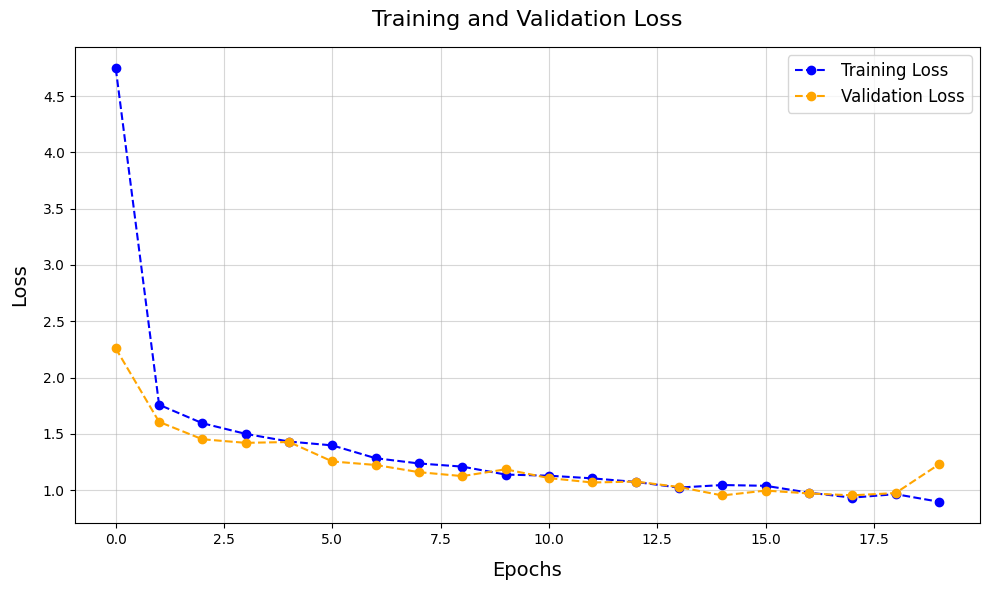

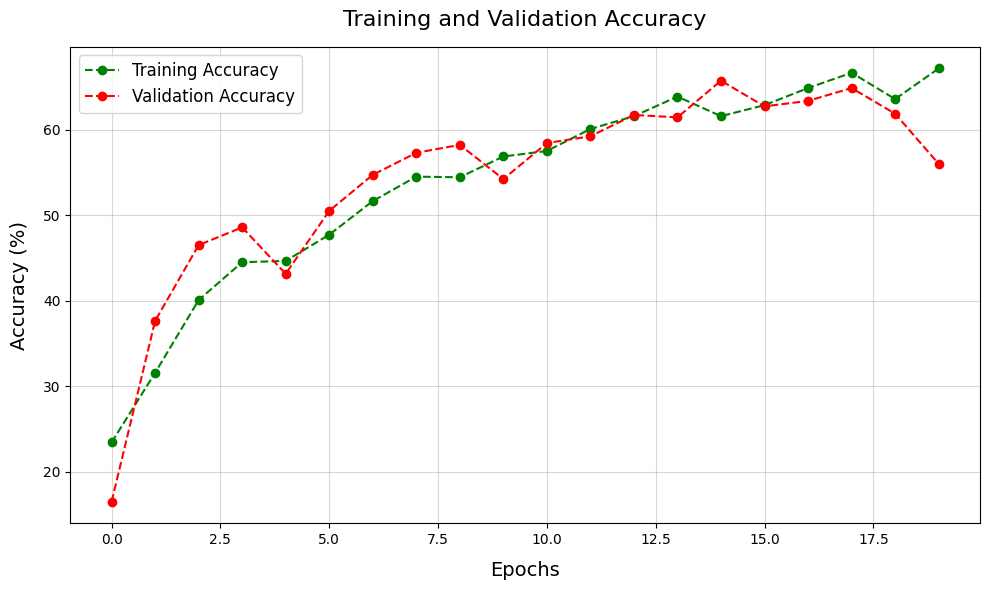


Validation Loss Improved (inf --> 1.702391)
Saving the model to CNN_model_trial_8.pth



Validation Loss Improved (1.702391 --> 1.598163)
Saving the model to CNN_model_trial_8.pth



Validation Loss Improved (1.598163 --> 1.472074)
Saving the model to CNN_model_trial_8.pth



Validation Loss Improved (1.472074 --> 1.435502)
Saving the model to CNN_model_trial_8.pth



Validation Loss Improved (1.435502 --> 1.292759)
Saving the model to CNN_model_trial_8.pth


...


Validation Loss Improved (0.832048 --> 0.811907)
Saving the model to CNN_model_trial_8.pth



Validation Loss Improved (0.811907 --> 0.776191)
Saving the model to CNN_model_trial_8.pth



Validation Loss Improved (0.776191 --> 0.766587)
Saving the model to CNN_model_trial_8.pth


Training Progress: 100%|██████████| 30/30 [02:00<00:00,  4.01s/epoch]


Loading the best model weights...


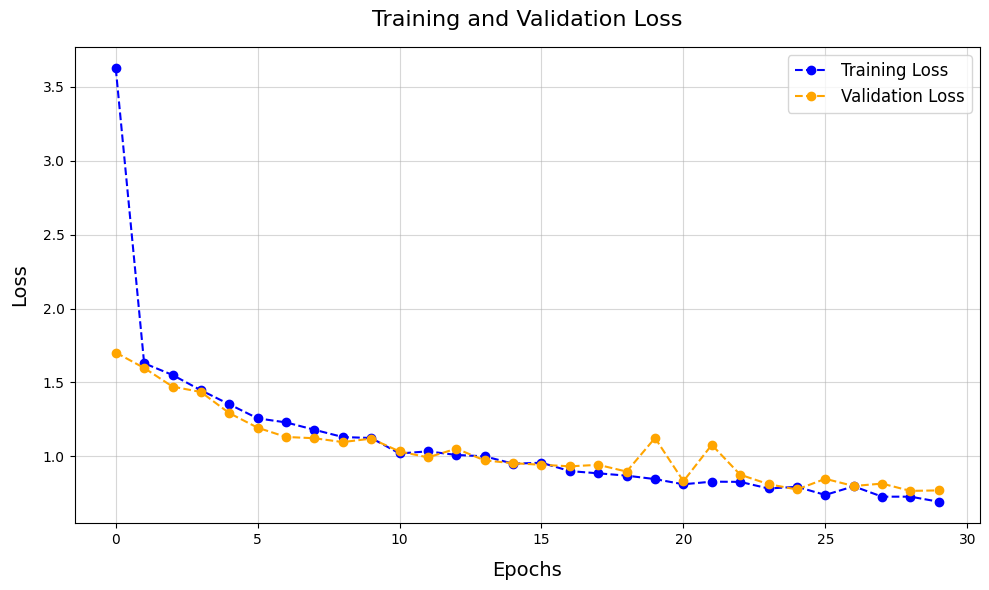

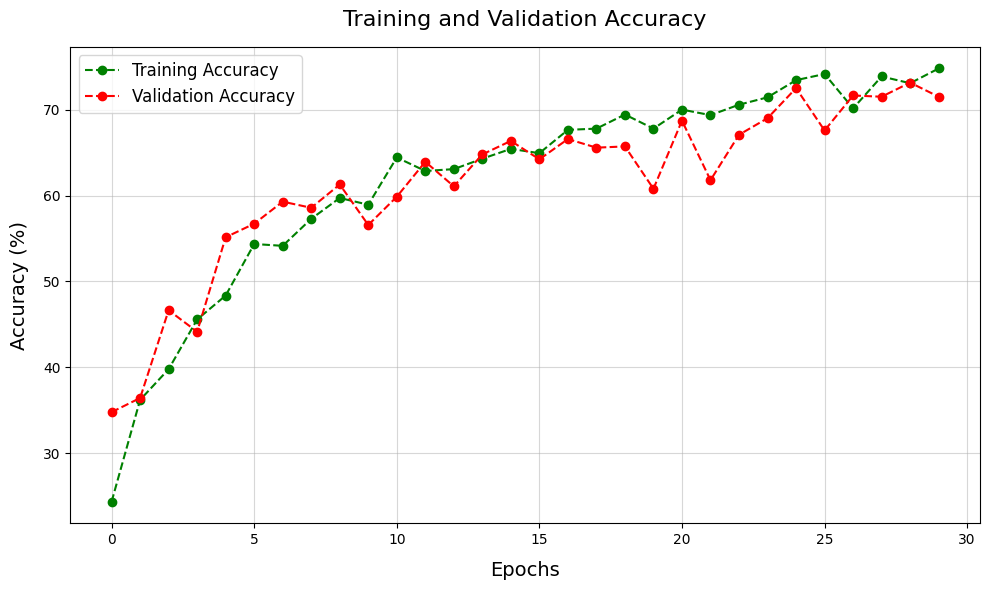


Validation Loss Improved (inf --> 3.789373)
Saving the model to CNN_model_trial_9.pth



Validation Loss Improved (3.789373 --> 1.929945)
Saving the model to CNN_model_trial_9.pth



Validation Loss Improved (1.929945 --> 1.725373)
Saving the model to CNN_model_trial_9.pth



Validation Loss Improved (1.725373 --> 1.588711)
Saving the model to CNN_model_trial_9.pth



Validation Loss Improved (1.588711 --> 1.443643)
Saving the model to CNN_model_trial_9.pth


...


Validation Loss Improved (1.165798 --> 1.156685)
Saving the model to CNN_model_trial_9.pth



Validation Loss Improved (1.156685 --> 1.048135)
Saving the model to CNN_model_trial_9.pth



Validation Loss Improved (1.048135 --> 0.992600)
Saving the model to CNN_model_trial_9.pth


Training Progress: 100%|██████████| 30/30 [02:35<00:00,  5.19s/epoch]



Loading the best model weights...


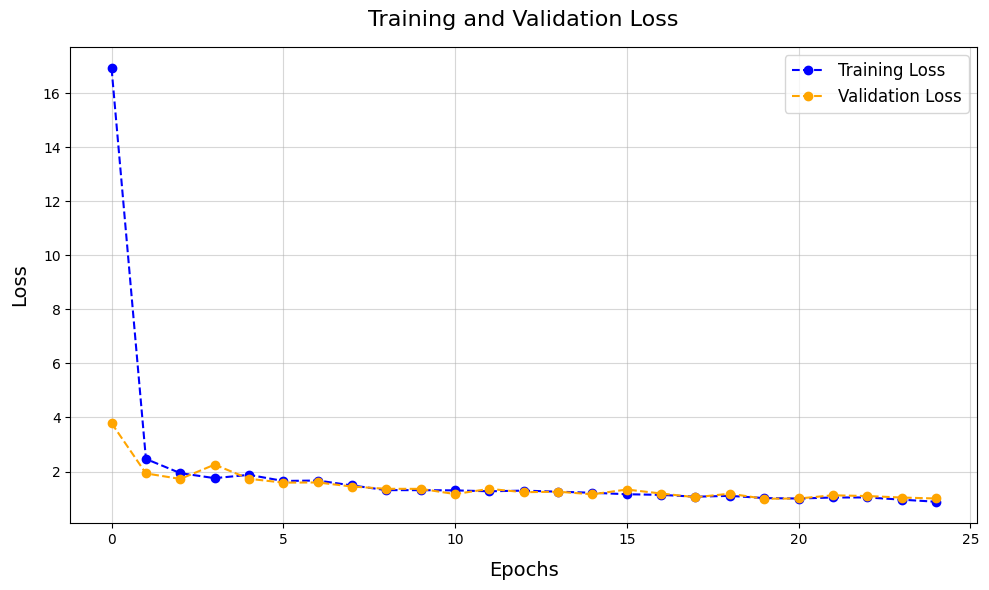

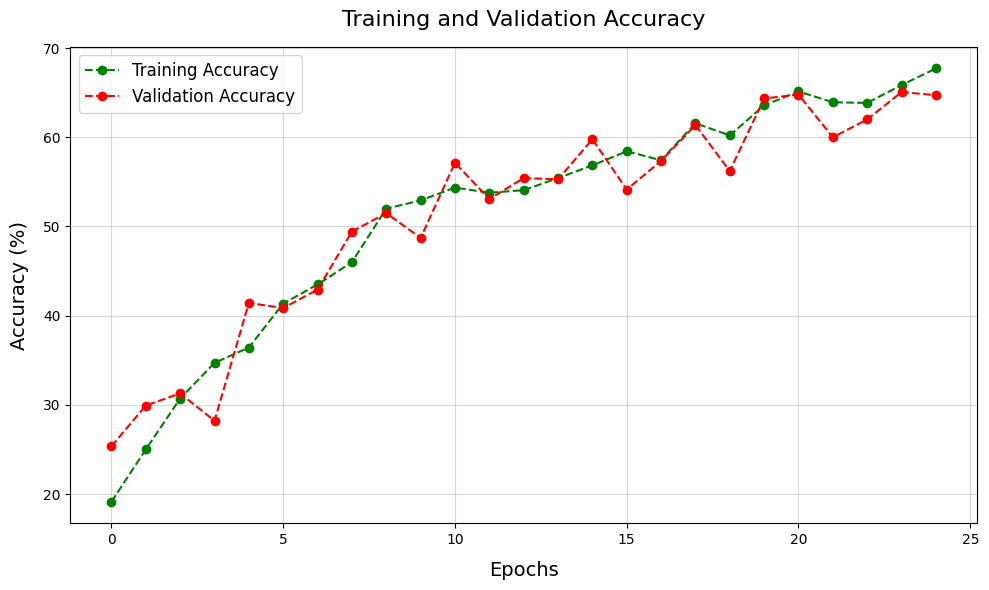


Optimization Complete!
Best Trial Results:
--------------------------------------------------
Validation Accuracy: 77.21%
Hyperparameters:
  num_of_layers: 3
  num_filters_3_layers: [32, 128, 128]
  learning_rate: 0.0001
  optimizer: Adam

Best Trial Summary
+--------------------------+----------------+
| Hyperparameter           | Value          |
+==========================+================+
| num_of_layers            | 3              |
+--------------------------+----------------+
| num_filters_3_layers     | [32, 128, 128] |
+--------------------------+----------------+
| learning_rate            | 0.0001         |
+--------------------------+----------------+
| optimizer                | Adam           |
+--------------------------+----------------+
| Best Validation Accuracy | 77.21%         |
+--------------------------+----------------+


In [66]:
# Create an Optuna study to optimize the objective function
study = optuna.create_study(direction='maximize')

# Run the optimization for 10 trials
print("=" * 50)
print("Starting Optuna Hyperparameter Optimization...")
print("=" * 50)
study.optimize(objective, n_trials=10, show_progress_bar=True)

# Display the best trial results
print("\n" + "=" * 50)
print("Optimization Complete!")
print("=" * 50)
print("Best Trial Results:")
print("-" * 50)
trial = study.best_trial
print(f"Validation Accuracy: {trial.value:.2f}%")
print("Hyperparameters:")
for key, value in trial.params.items():
    print(f"  {key}: {value}")
print("=" * 50)


# Create a summary table for the best trial
summary_table = pd.DataFrame({
    "Hyperparameter": list(trial.params.keys()) + ["Best Validation Accuracy"],
    "Value": [str(value) for value in trial.params.values()] + [f"{trial.value:.2f}%"]
})

# Display the summary table in a visually appealing format
print("\n" + "=" * 50)
print("Best Trial Summary")
print("=" * 50)
print(summary_table.to_markdown(index=False, tablefmt="grid"))

**BUILD THE CUSTOM MODEL**

In [67]:
# initiate the model with the best hyperparameters
num_classes = 7

In [68]:
class CNNet(nn.Module):
    """
    A Convolutional Neural Network (CNN) model for image classification.

    The model consists of four convolutional layers followed by three fully connected layers.
    Each convolutional layer includes batch normalization, ReLU activation, and max pooling.
    """
    def __init__(self):
        super(CNNet, self).__init__()
        
        # Define the first convolutional block
        self.layer1 = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=64, kernel_size=3, padding=1),  # Convolutional layer
            nn.BatchNorm2d(64),  # Batch normalization for faster convergence
            nn.ReLU(),  # Activation function
            nn.MaxPool2d(kernel_size=2, stride=2)  # Max pooling to reduce spatial dimensions
        )
        
        # Define the second convolutional block
        self.layer2 = nn.Sequential(
            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        
        # Define the third convolutional block
        self.layer3 = nn.Sequential(
            nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        
        # Define the fourth convolutional block
        self.layer4 = nn.Sequential(
            nn.Conv2d(in_channels=256, out_channels=512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        
        # Fully connected layers
        self.fc1 = nn.Linear(in_features=512 * 14 * 14, out_features=512)  # First fully connected layer
        self.fc2 = nn.Linear(in_features=512, out_features=128)  # Second fully connected layer
        self.fc3 = nn.Linear(in_features=128, out_features=num_classes)  # Output layer for classification

    def forward(self, x):
        """
        Forward pass of the model.

        Parameters:
        x (torch.Tensor): Input tensor of shape (batch_size, channels, height, width).

        Returns:
        torch.Tensor: Output tensor with predictions for each class.
        """
        # Ensure the input tensor has the correct shape
        x = x.view(-1, 3, img_h, img_w)
        
        # Pass through the convolutional layers
        out1 = self.layer1(x)
        out2 = self.layer2(out1)
        out3 = self.layer3(out2)
        out4 = self.layer4(out3)
        
        # Flatten the output of the last convolutional layer
        out = out4.view(out4.size(0), -1)
        
        # Pass through the fully connected layers with ReLU activations
        out = F.relu(self.fc1(out))
        out = F.relu(self.fc2(out))
        out = self.fc3(out)  # Output layer (no activation, as it will be handled by the loss function)
        
        return out

# Instantiate the CNN model
CNN_model = CNNet()

In [69]:
# Move the CNN model to the specified device (GPU or CPU)
CNN_model = CNN_model.to(device)

# Define the input size for the model summary (3 channels for RGB, 224x224 image dimensions)
input_size = (3, 224, 224)

# Print the model summary with enhanced formatting
print("=" * 80)
print(f"{'MODEL SUMMARY':^80}")
print("=" * 80)
print(summary(CNN_model, input_size, device=device.type))
print("=" * 80)

                                 MODEL SUMMARY                                  
Layer (type:depth-idx)                   Output Shape              Param #
├─Sequential: 1-1                        [-1, 64, 112, 112]        --
|    └─Conv2d: 2-1                       [-1, 64, 224, 224]        1,792
|    └─BatchNorm2d: 2-2                  [-1, 64, 224, 224]        128
|    └─ReLU: 2-3                         [-1, 64, 224, 224]        --
|    └─MaxPool2d: 2-4                    [-1, 64, 112, 112]        --
├─Sequential: 1-2                        [-1, 128, 56, 56]         --
|    └─Conv2d: 2-5                       [-1, 128, 112, 112]       73,856
|    └─BatchNorm2d: 2-6                  [-1, 128, 112, 112]       256
|    └─ReLU: 2-7                         [-1, 128, 112, 112]       --
|    └─MaxPool2d: 2-8                    [-1, 128, 56, 56]         --
├─Sequential: 1-3                        [-1, 256, 28, 28]         --
|    └─Conv2d: 2-9                       [-1, 256, 56, 56]       

In [84]:
criterion = nn.CrossEntropyLoss().to(device)
optimizer = torch.optim.Adam(CNN_model.parameters(), lr=1e-3)

AttributeError: 'ellipsis' object has no attribute 'parameters'

**Fit the model using Validation set for the best model selection**

Training Progress:   1%|          | 1/150 [00:36<1:29:38, 36.10s/epoch]


Epoch 1/150
Training Loss: 2.0433 | Training Accuracy: 40.93%
Validation Loss: 1.2515 | Validation Accuracy: 53.53%

Validation Loss Improved (inf --> 1.251527)
Saving the model to CNN_model.pth

Epoch 2/150
Training Loss: 1.0332 | Training Accuracy: 61.45%
Validation Loss: 1.0359 | Validation Accuracy: 62.91%

Validation Loss Improved (1.251527 --> 1.035921)
Saving the model to CNN_model.pth


Training Progress:   1%|▏         | 2/150 [01:12<1:29:03, 36.11s/epoch]


Epoch 3/150
Training Loss: 0.8690 | Training Accuracy: 67.80%
Validation Loss: 0.7862 | Validation Accuracy: 70.48%

Validation Loss Improved (1.035921 --> 0.786195)
Saving the model to CNN_model.pth


Training Progress:   3%|▎         | 4/150 [02:24<1:27:56, 36.14s/epoch]

...


Epoch 63/150
Training Loss: 0.0539 | Training Accuracy: 98.29%
Validation Loss: 0.1095 | Validation Accuracy: 97.02%


Training Progress:  43%|████▎     | 64/150 [38:29<51:33, 35.97s/epoch]


Epoch 64/150
Training Loss: 0.0657 | Training Accuracy: 97.94%
Validation Loss: 0.1064 | Validation Accuracy: 96.86%


Training Progress: 100%|██████████| 150/150 [39:05<00:00, 15.63s/epoch]


Epoch 65/150
Training Loss: 0.0515 | Training Accuracy: 98.12%
Validation Loss: 0.1127 | Validation Accuracy: 97.48%

Loading the best model weights...


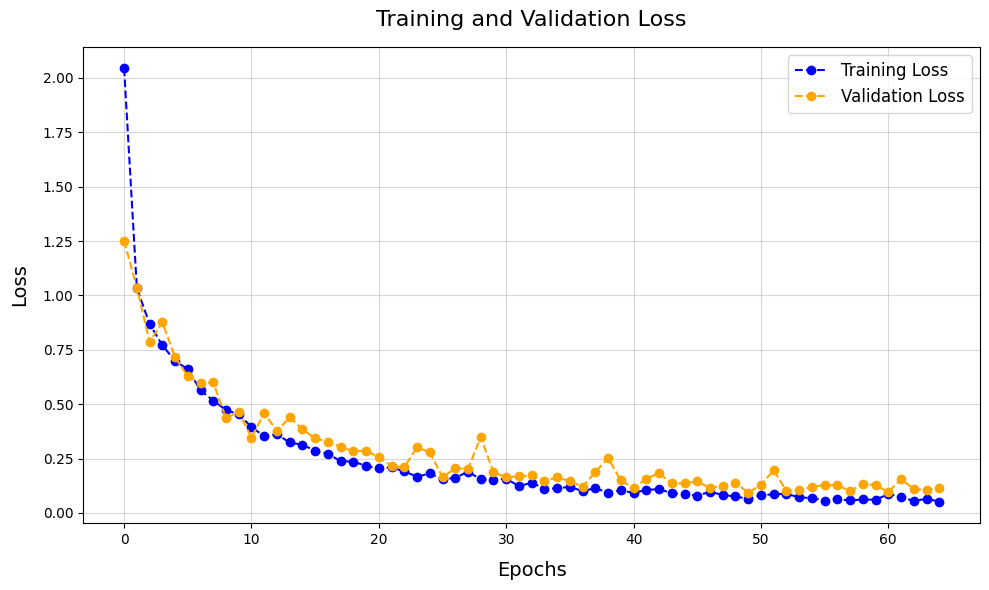

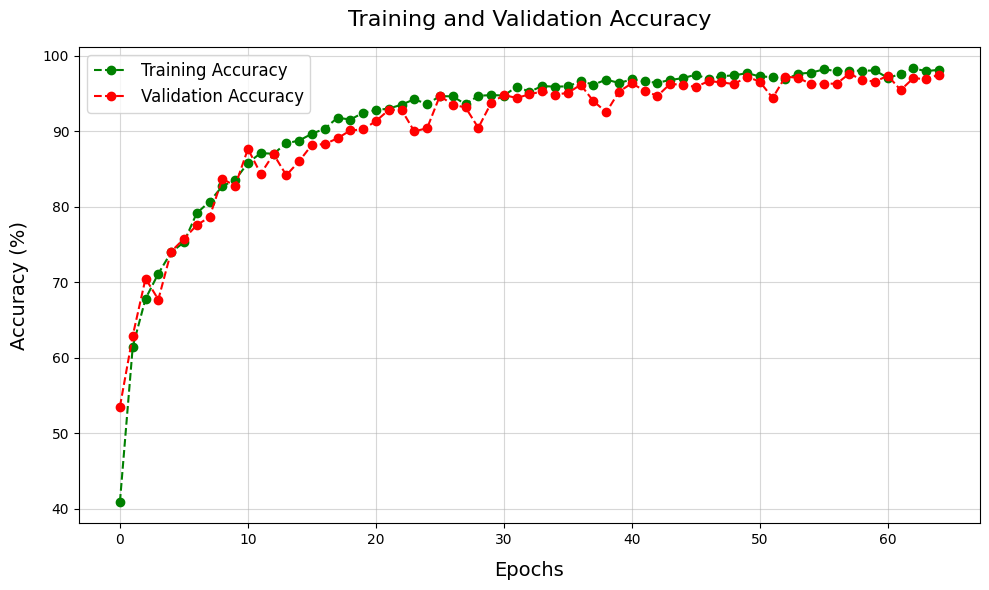

In [71]:
epochs = 150
patience = 15
model_filename = 'CNN_model.pth'
model = CNN_model
start_time = time.time()
CNN_model_fitted, total_loss_train, total_loss_val, total_acc_train, total_acc_val = train_and_validate_model(
                        model, train_loader, val_loader,test_loader, criterion,patience, optimizer, device, epochs, model_filename, verbose=True)
end_time = time.time()

In [72]:
# Calculate the total training and validation time
total_time = end_time - start_time

# Print the total time in a more visually appealing format
print("=" * 60)
print(f"{'Training and Validation Time':^60}")
print("=" * 60)
print(f"Total Time: {total_time / 60:.2f} minutes")
print("=" * 60)

                Training and Validation Time                
Total Time: 39.09 minutes


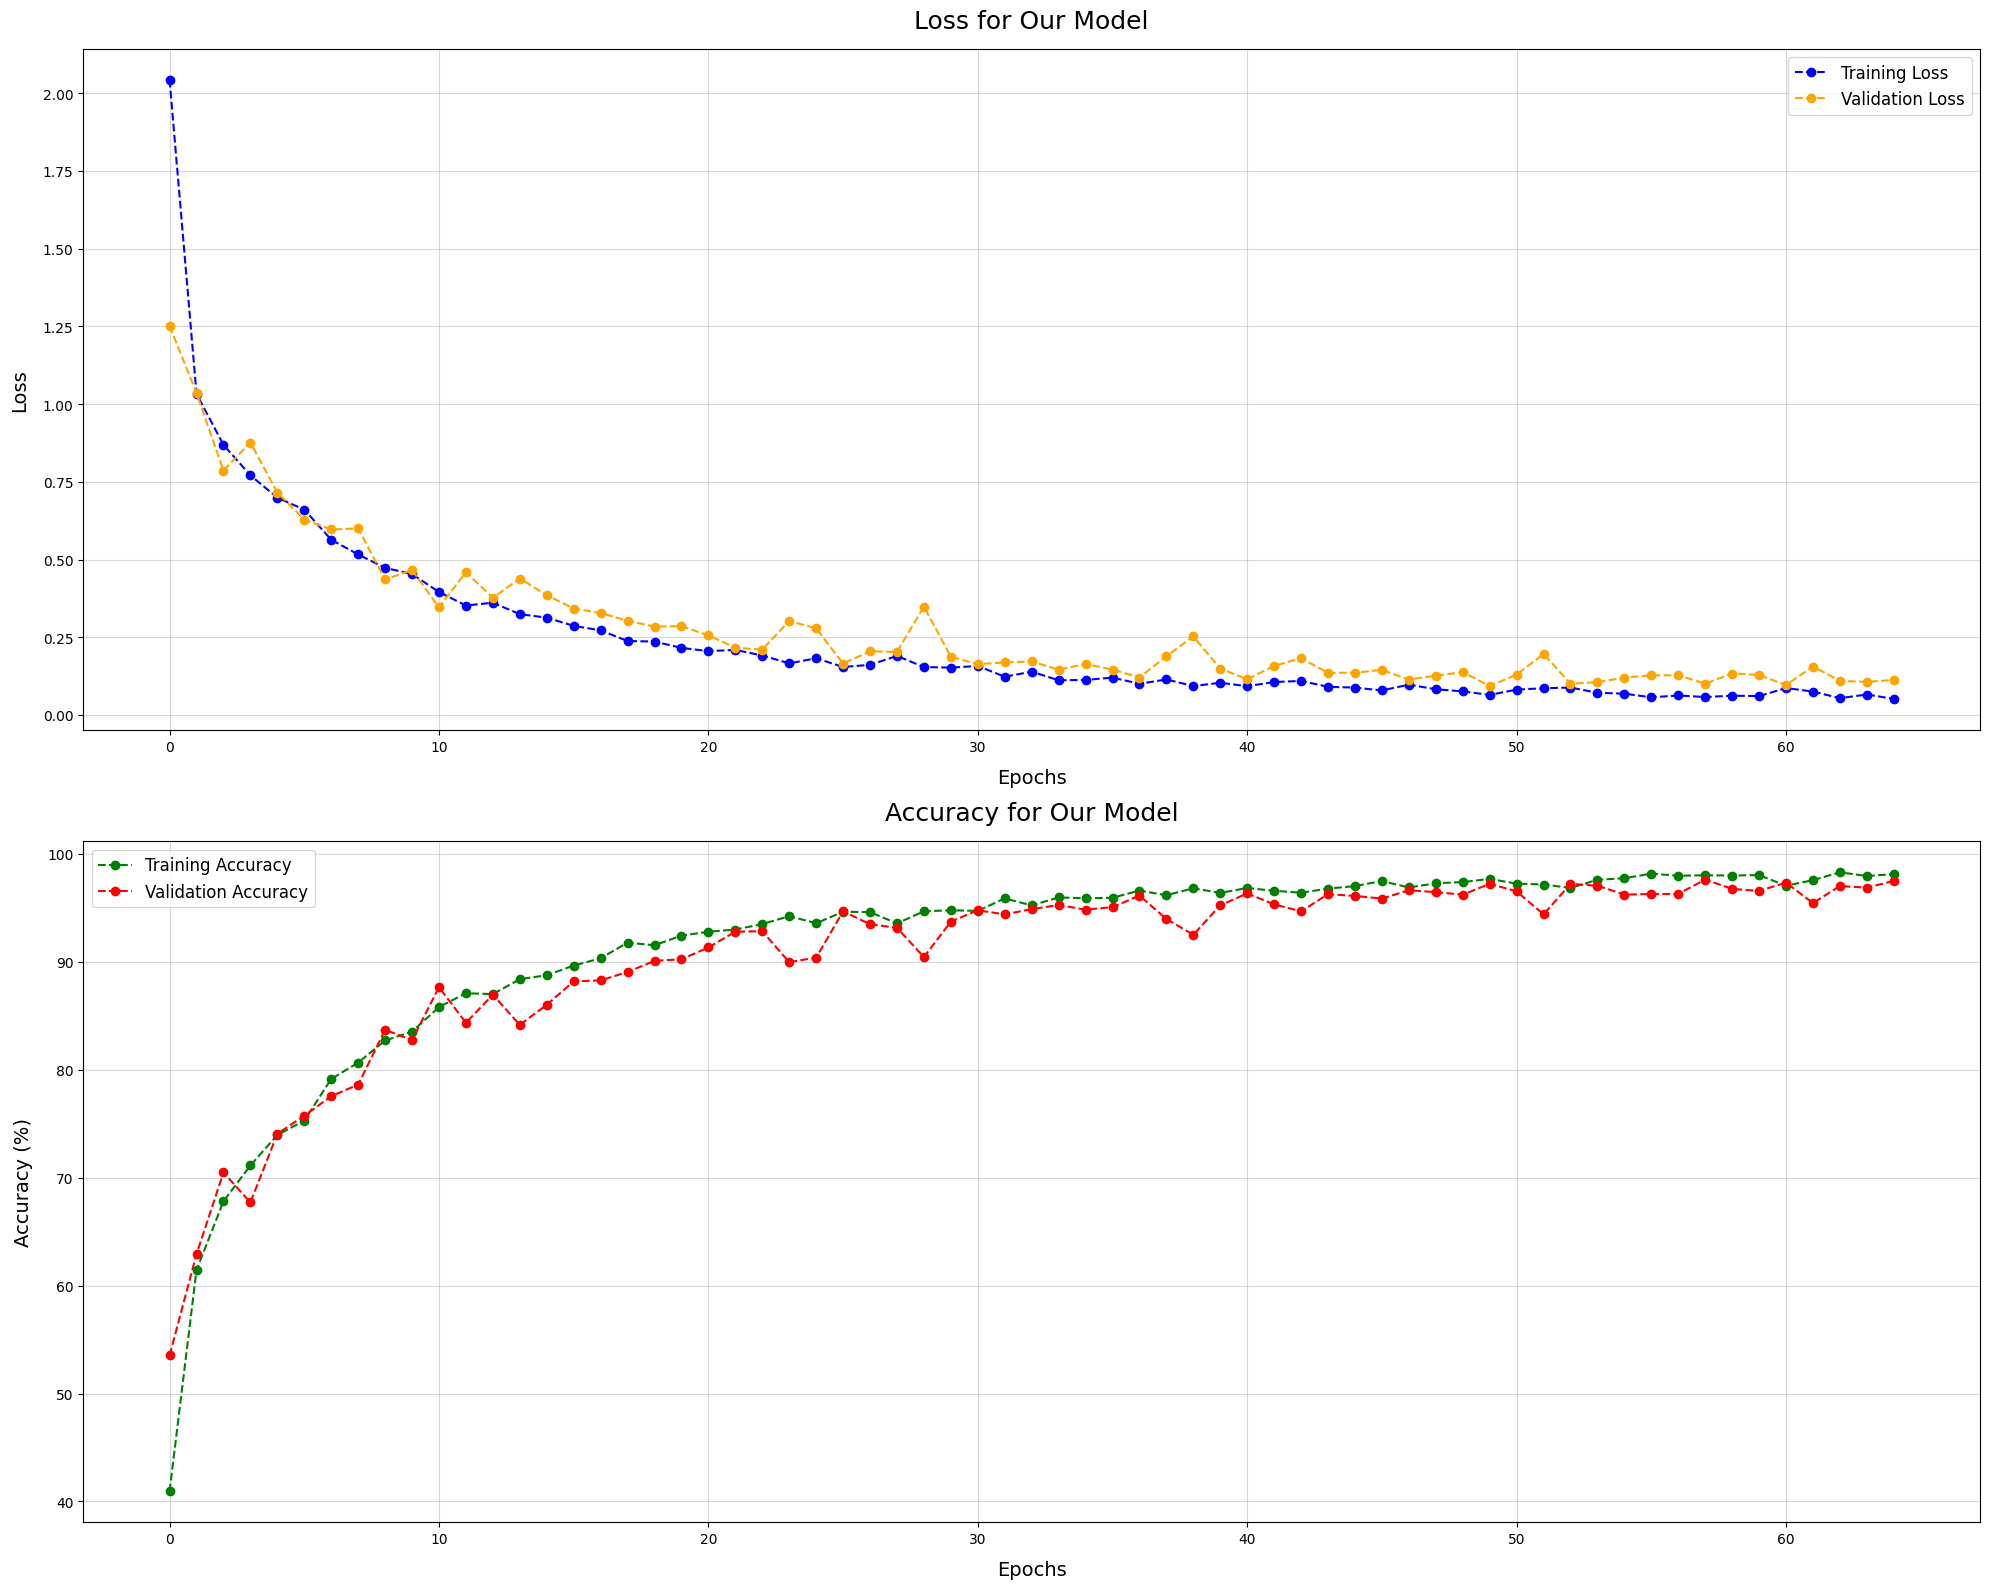


Final Metrics Summary
+---------------------------+------------+
| Metric                    |      Value |
+===========================+============+
| Final Training Loss       |  0.0515114 |
+---------------------------+------------+
| Final Validation Loss     |  0.112725  |
+---------------------------+------------+
| Final Training Accuracy   | 98.1152    |
+---------------------------+------------+
| Final Validation Accuracy | 97.4842    |
+---------------------------+------------+


In [73]:
# Create a figure with a specified size
fig = plt.figure(num=2, figsize=(20, 16))

# Add subplots for loss and accuracy
fig1 = fig.add_subplot(2, 1, 1)  # First subplot for loss
fig2 = fig.add_subplot(2, 1, 2)  # Second subplot for accuracy

# Plot training and validation loss
fig1.plot(total_loss_train, label='Training Loss', color='blue', linestyle='--', marker='o')
fig1.plot(total_loss_val, label='Validation Loss', color='orange', linestyle='--', marker='o')
fig1.set_title('Loss for Our Model', fontsize=18, pad=15)  # Set title with improved formatting
fig1.set_xlabel('Epochs', fontsize=14, labelpad=10)  # Add x-axis label
fig1.set_ylabel('Loss', fontsize=14, labelpad=10)  # Add y-axis label
fig1.legend(fontsize=12)  # Add legend with improved font size
fig1.grid(alpha=0.5)  # Add gridlines for better readability

# Plot training and validation accuracy
fig2.plot(total_acc_train, label='Training Accuracy', color='green', linestyle='--', marker='o')
fig2.plot(total_acc_val, label='Validation Accuracy', color='red', linestyle='--', marker='o')
fig2.set_title('Accuracy for Our Model', fontsize=18, pad=15)  # Set title with improved formatting
fig2.set_xlabel('Epochs', fontsize=14, labelpad=10)  # Add x-axis label
fig2.set_ylabel('Accuracy (%)', fontsize=14, labelpad=10)  # Add y-axis label
fig2.legend(fontsize=12)  # Add legend with improved font size
fig2.grid(alpha=0.5)  # Add gridlines for better readability

# Adjust layout to prevent overlapping
plt.tight_layout()

# Display the plots
plt.show()

# Add a summary table for the final metrics
final_metrics = pd.DataFrame({
    'Metric': ['Final Training Loss', 'Final Validation Loss', 'Final Training Accuracy', 'Final Validation Accuracy'],
    'Value': [
        total_loss_train[-1], 
        total_loss_val[-1], 
        total_acc_train[-1], 
        total_acc_val[-1]
    ]
})

# Display the summary table as a visual
print("\n" + "=" * 50)
print("Final Metrics Summary")
print("=" * 50)
print(final_metrics.to_markdown(index=False, tablefmt="grid"))

In [74]:
# Ensure the model is loaded on the CPU for evaluation
best_model_path = 'CNN_model.pth'
print(f"Loading the best model from: {best_model_path}...")
best_model_state = torch.load(best_model_path, map_location='cpu')
CNN_model.load_state_dict(best_model_state)

# Move the model to the CPU
device = torch.device('cpu')
CNN_model.to(device)

# Evaluate the model on the test set
print("\nEvaluating the model on the test set...")
test_accuracy = test_model(CNN_model, test_loader, device)

# Display the results with improved formatting
print("\n" + "=" * 60)
print(f"🎉 Best Model's Test Accuracy: {test_accuracy:.2f}%")
print("=" * 60)

Loading the best model from: CNN_model.pth...

Evaluating the model on the test set...

🎉 Best Model's Test Accuracy: 96.94%



🔍 Generating Classification Report for CNN Model...


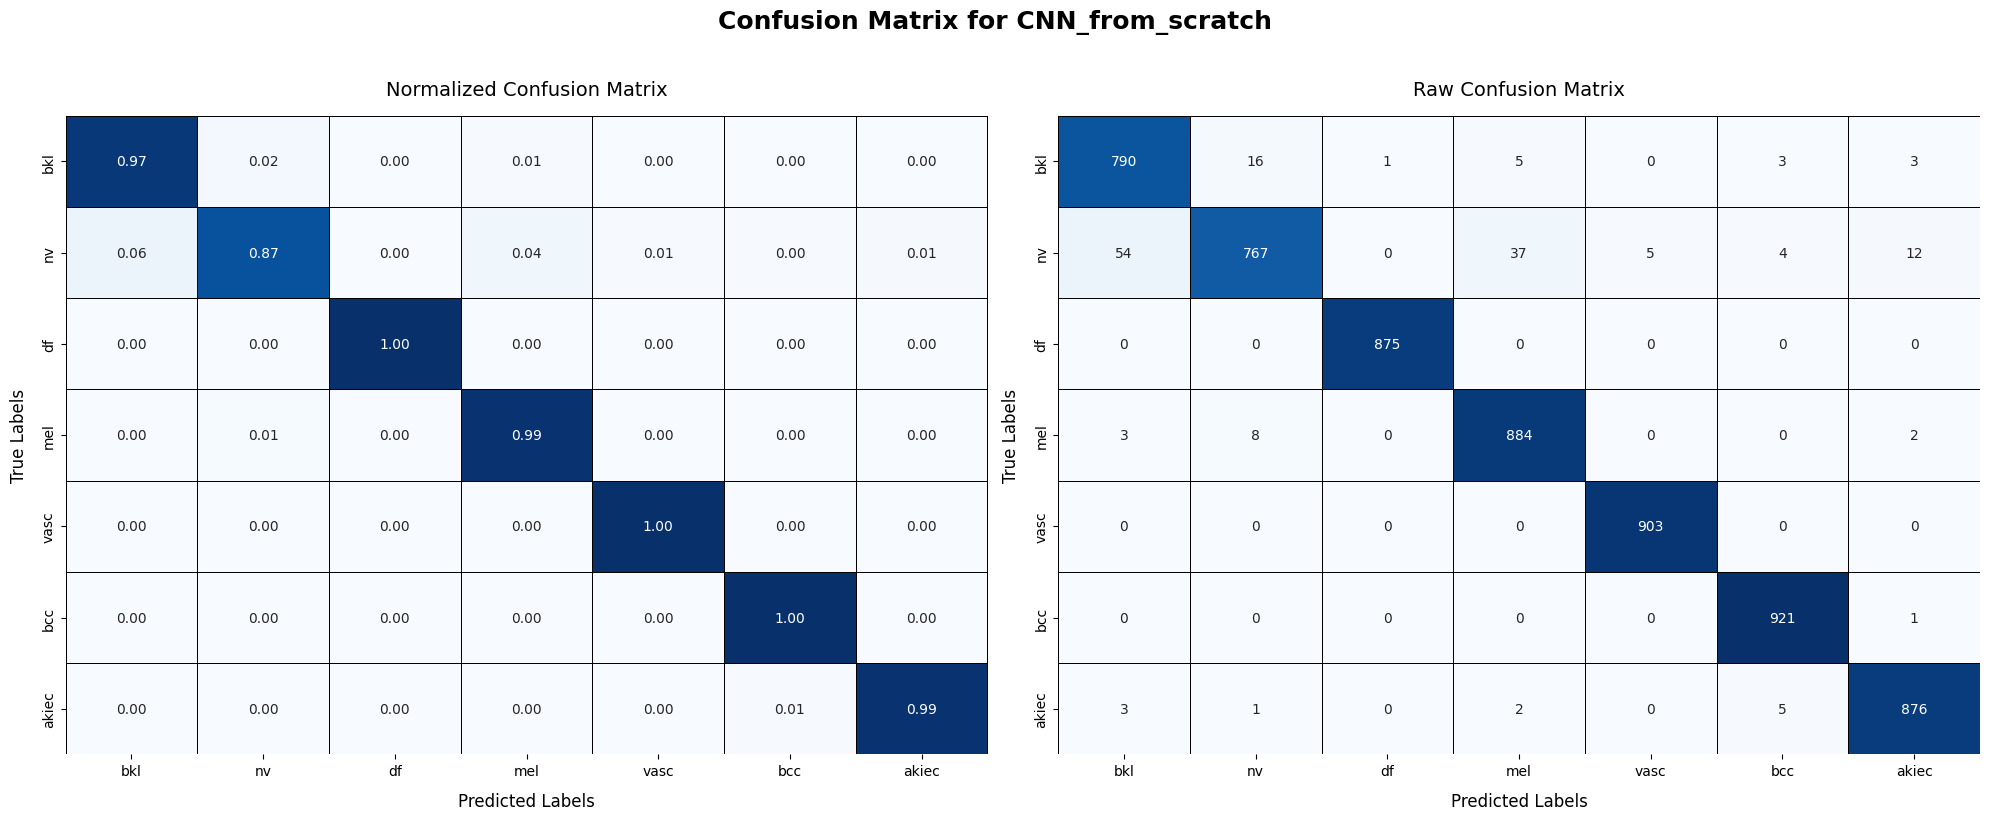

-------------------------------------------------------
Classification Report for CNN_from_scratch:

              precision    recall  f1-score   support

         bkl      0.929     0.966     0.947       818
          nv      0.968     0.873     0.918       879
          df      0.999     1.000     0.999       875
         mel      0.953     0.986     0.969       897
        vasc      0.994     1.000     0.997       903
         bcc      0.987     0.999     0.993       922
       akiec      0.980     0.988     0.984       887

    accuracy                          0.973      6181
   macro avg      0.973     0.973     0.972      6181
weighted avg      0.974     0.973     0.973      6181

-------------------------------------------------------

✅ Classification Report Generated Successfully!


In [75]:
# Generate and display the classification report for the CNN model
# This function evaluates the model on the test set and prints a detailed report

print("\n" + "=" * 60)
print("🔍 Generating Classification Report for CNN Model...")
print("=" * 60)

# Call the function to generate the classification report
conf_report(CNN_model, test_loader, 'CNN_from_scratch')

# Add a completion message for better user feedback
print("\n" + "=" * 60)
print("✅ Classification Report Generated Successfully!")
print("=" * 60)

# Test run the model

**Objective**: runnig the trained model with sample image to see the output.

In [97]:
# essential imports
import torch
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt

In [98]:
class CNNet(torch.nn.Module):
    def __init__(self):
        super(CNNet, self).__init__()
        self.layer1 = torch.nn.Sequential(
            torch.nn.Conv2d(3, 64, kernel_size=3, padding=1),
            torch.nn.BatchNorm2d(64),
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(kernel_size=2, stride=2)
        )
        self.layer2 = torch.nn.Sequential(
            torch.nn.Conv2d(64, 128, kernel_size=3, padding=1),
            torch.nn.BatchNorm2d(128),
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(kernel_size=2, stride=2)
        )
        self.layer3 = torch.nn.Sequential(
            torch.nn.Conv2d(128, 256, kernel_size=3, padding=1),
            torch.nn.BatchNorm2d(256),
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(kernel_size=2, stride=2)
        )
        self.layer4 = torch.nn.Sequential(
            torch.nn.Conv2d(256, 512, kernel_size=3, padding=1),
            torch.nn.BatchNorm2d(512),
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(kernel_size=2, stride=2)
        )
        # Adjust the fully connected layer input based on your input image size (224x224)
        self.fc1 = torch.nn.Linear(512 * 14 * 14, 512)
        self.fc2 = torch.nn.Linear(512, 128)
        self.fc3 = torch.nn.Linear(128, 7)  # assuming 7 classes

    def forward(self, x):
        # Ensure the input is of shape (batch, channels, height, width)
        x = x.view(-1, 3, 224, 224)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = x.view(x.size(0), -1)
        x = torch.nn.functional.relu(self.fc1(x))
        x = torch.nn.functional.relu(self.fc2(x))
        x = self.fc3(x)
        return x

In [99]:
# Define the class names (update if necessary)
classes = ['bkl', 'nv', 'df', 'mel', 'vasc', 'bcc', 'akiec']

In [100]:
# Set device and load the trained model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CNNet()
model_path = 'CNN_model.pth'
model.load_state_dict(torch.load(model_path, map_location=device))
model.to(device)
model.eval()  # Set model to evaluation mode

CNNet(
  (layer1): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (layer2): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (layer3): Sequential(
    (0): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (layer4): Sequential(
    (0): Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): Bat

In [101]:
# Define the image transformation (should match your validation/test transforms)
img_h, img_w = 224, 224
norm_means = [0.77148203, 0.55764165, 0.58345652]
norm_std = [0.12655577, 0.14245141, 0.15189891]

In [102]:
transform = transforms.Compose([
    transforms.Resize((img_h, img_w)),
    transforms.ToTensor(),
    transforms.Normalize(norm_means, norm_std)
])

In [107]:
def predict_image(image_path):
    # Load and transform the image
    image = Image.open(image_path).convert("RGB")
    input_tensor = transform(image)
    input_tensor = input_tensor.unsqueeze(0)  # Add batch dimension

    # Run inference
    with torch.no_grad():
        output = model(input_tensor.to(device))
        _, predicted_idx = torch.max(output, 1)
        predicted_class = classes[predicted_idx.item()]

    # Display the image and prediction
    plt.imshow(image)
    plt.title(f"Predicted: {predicted_class}")
    plt.axis('off')
    plt.show()

    print(f"Predicted class: {predicted_class}")
    return predicted_class

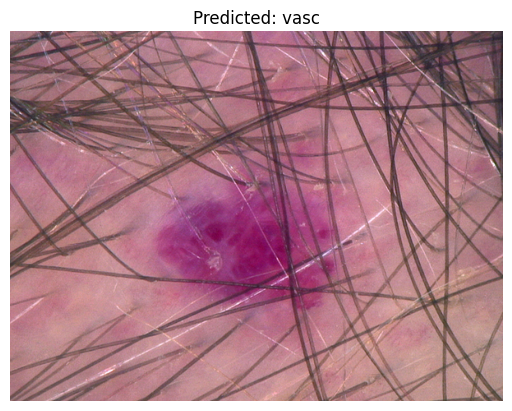

Predicted class: vasc


'vasc'

In [108]:

image_path = "/home/asad/Thesis Practical part/dataset/HAM10000_images_part_1/ISIC_0027790.jpg" # <- correct class: akiec
predict_image(image_path)